In [21]:
import sys
sys.path.append('../')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from data_loader import PairData

data   = PairData('../../data/real_pair_XOM_CVX.csv')
prices = data.s          # shape (2, N)
labels = data.labels     # ['XOM', 'CVX']
N      = prices.shape[1]

# timestamps → dates
df_raw = pd.read_csv('../../data/real_pair_XOM_CVX.csv', index_col=0, parse_dates=True)
df_raw.index = pd.to_datetime(df_raw.index, unit='s')
dates  = df_raw.index

train_end = 3 * N // 4

print(f'Loaded {N} days  ({dates[0].date()} → {dates[-1].date()})')
print(f'Train: {dates[0].date()} – {dates[train_end-1].date()}  ({train_end} days)')
print(f'Test:  {dates[train_end].date()} – {dates[-1].date()}  ({N - train_end} days)')

Loaded 5032 days  (2006-05-16 → 2026-05-15)
Train: 2006-05-16 – 2021-05-12  (3774 days)
Test:  2021-05-13 – 2026-05-15  (1258 days)


/tmp/ipykernel_928912/2633641450.py:15: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_raw = pd.read_csv('../../data/real_pair_XOM_CVX.csv', index_col=0, parse_dates=True)


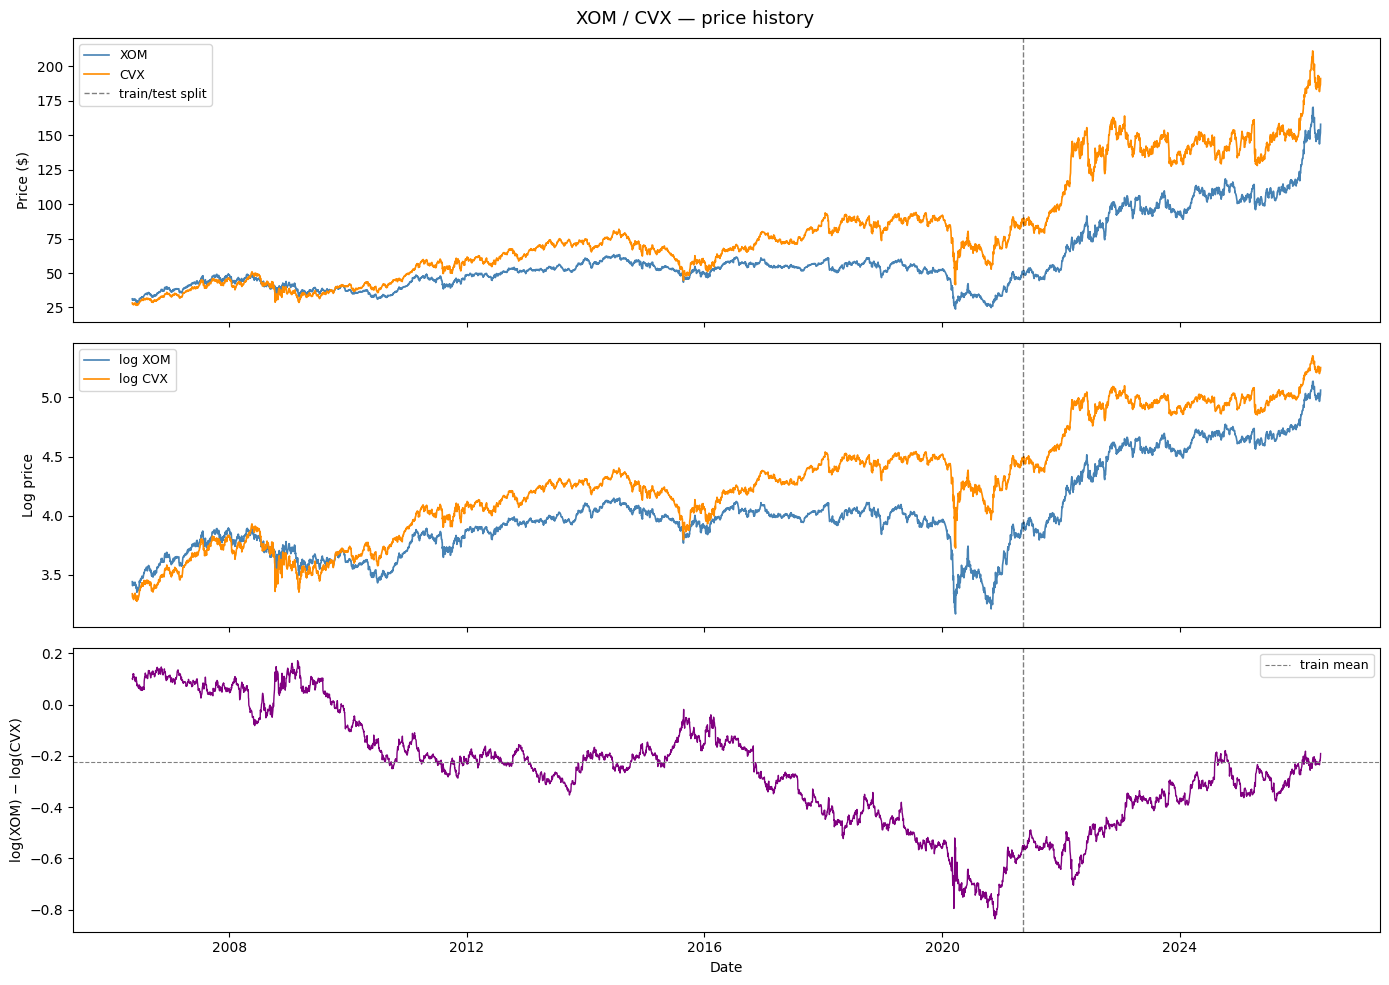

In [22]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
fig.suptitle('XOM / CVX — price history', fontsize=13)

log_xom = np.log(prices[0])
log_cvx = np.log(prices[1])

# ── Panel 1: raw prices ───────────────────────────────────────────────────
ax = axes[0]
ax.plot(dates, prices[0], color='steelblue',  lw=1.2, label=labels[0])
ax.plot(dates, prices[1], color='darkorange', lw=1.2, label=labels[1])
ax.axvline(dates[train_end], color='black', lw=1, ls='--', alpha=0.5, label='train/test split')
ax.set_ylabel('Price ($)')
ax.legend(fontsize=9)

# ── Panel 2: log prices ───────────────────────────────────────────────────
ax = axes[1]
ax.plot(dates, log_xom, color='steelblue',  lw=1.2, label=f'log {labels[0]}')
ax.plot(dates, log_cvx, color='darkorange', lw=1.2, label=f'log {labels[1]}')
ax.axvline(dates[train_end], color='black', lw=1, ls='--', alpha=0.5)
ax.set_ylabel('Log price')
ax.legend(fontsize=9)

# ── Panel 3: raw log spread (β=1, no OLS yet) ────────────────────────────
ax = axes[2]
raw_spread = log_xom - log_cvx
ax.plot(dates, raw_spread, color='purple', lw=1.0)
ax.axvline(dates[train_end], color='black', lw=1, ls='--', alpha=0.5)
ax.axhline(raw_spread[:train_end].mean(), color='gray', lw=0.8, ls='--', label='train mean')
ax.set_ylabel(f'log({labels[0]}) − log({labels[1]})')
ax.legend(fontsize=9)
ax.set_xlabel('Date')

plt.tight_layout()
plt.show()

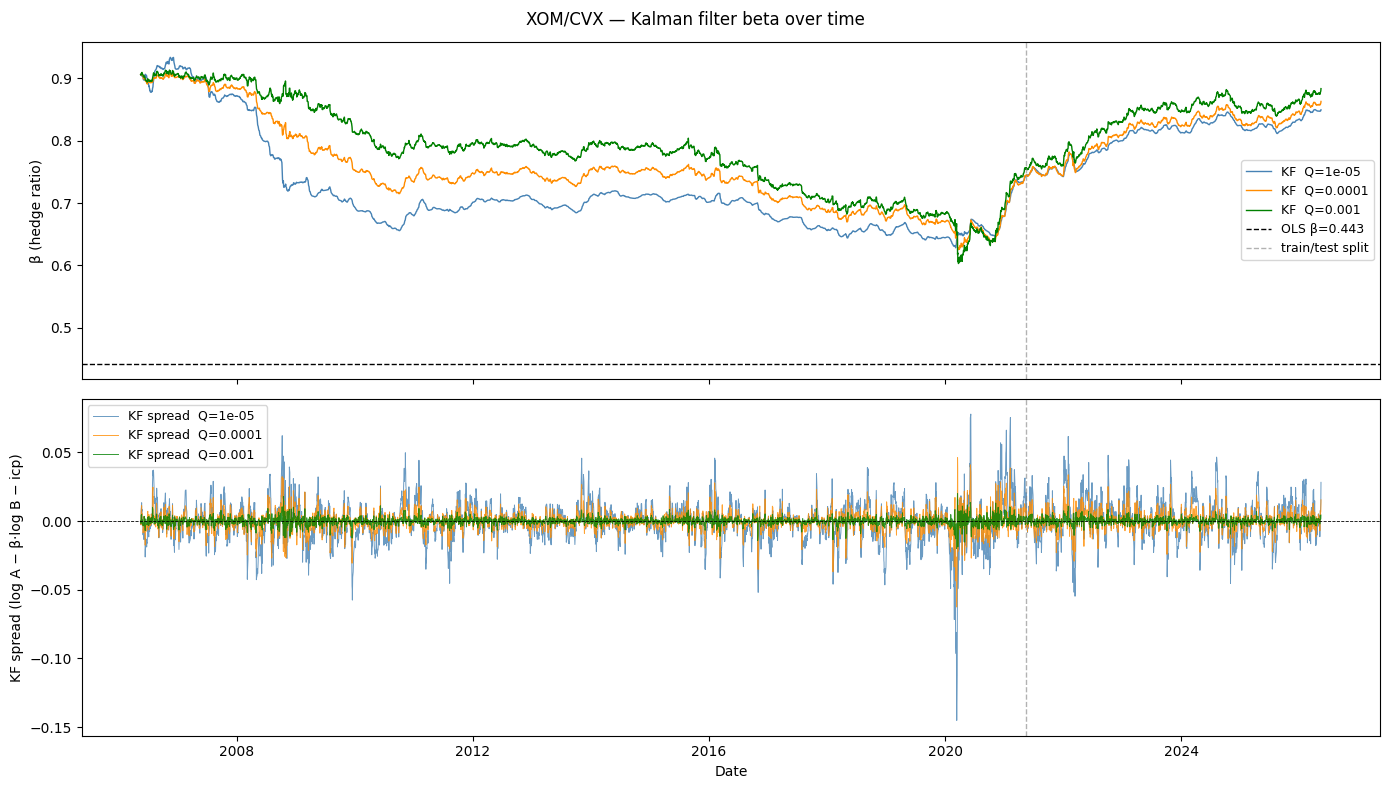

OLS beta (train):   0.4427
KF Q=1e-05  beta at end of train: 0.7429  beta at end of test: 0.8496  total drift: -0.0566
KF Q=1e-04  beta at end of train: 0.7443  beta at end of test: 0.8630  total drift: -0.0431
KF Q=1e-03  beta at end of train: 0.7553  beta at end of test: 0.8836  total drift: -0.0226


In [23]:
# ── Kalman filter for time-varying beta ──────────────────────────────────
#
# State-space model (random walk on parameters):
#   observation : log_A[t] = [log_B[t], 1] @ [beta_t, intercept_t] + e,  e ~ N(0, R)
#   transition  : [beta, icp]_t = [beta, icp]_{t-1} + w,                  w ~ N(0, Q)
#
# Q controls how fast beta is allowed to change.
# Smaller Q → smoother beta (slower adaptation).
# Larger  Q → beta tracks recent data more aggressively.

def kalman_beta(log_A, log_B, Q_var=1e-4, R_var=1e-2):
    """
    Returns arrays: beta[t], intercept[t], spread[t] for all t.
    State = [beta, intercept].
    """
    n   = len(log_A)
    Q   = np.eye(2) * Q_var          # state noise covariance
    R   = float(R_var)               # obs noise variance

    # initialise with OLS on first 60 days
    init = 60
    X0   = np.column_stack([log_B[:init], np.ones(init)])
    c0, _, _, _ = np.linalg.lstsq(X0, log_A[:init], rcond=None)

    x = c0.copy()                    # [beta, intercept]
    P = np.eye(2) * 1.0              # initial state covariance (uncertain)

    betas = np.empty(n); icps = np.empty(n)

    for t in range(n):
        # predict (random walk: F = I)
        P = P + Q

        # observation matrix
        H = np.array([log_B[t], 1.0])

        # innovation
        y = log_A[t] - H @ x
        S = H @ P @ H + R
        K = P @ H / S               # Kalman gain (2,)

        # update
        x = x + K * y
        P = P - np.outer(K, H) @ P

        betas[t] = x[0]
        icps[t]  = x[1]

    spread_kf = log_A - betas * log_B - icps
    return betas, icps, spread_kf

# run with a few Q settings to show sensitivity
Q_values = [1e-5, 1e-4, 1e-3]
results_kf = {}
for q in Q_values:
    b, icp, sp = kalman_beta(log_xom, log_cvx, Q_var=q)
    results_kf[q] = (b, icp, sp)

# also compute static OLS beta for comparison
X_ols  = np.column_stack([log_cvx[:train_end], np.ones(train_end)])
c_ols, _, _, _ = np.linalg.lstsq(X_ols, log_xom[:train_end], rcond=None)
beta_ols, icp_ols = float(c_ols[0]), float(c_ols[1])

# ── Plot ──────────────────────────────────────────────────────────────────
colors = ['steelblue', 'darkorange', 'green']
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
fig.suptitle('XOM/CVX — Kalman filter beta over time', fontsize=12)

ax = axes[0]
for (q, (b, _, _)), c in zip(results_kf.items(), colors):
    ax.plot(dates, b, lw=1.0, color=c, label=f'KF  Q={q}')
ax.axhline(beta_ols, color='black', lw=1.0, ls='--', label=f'OLS β={beta_ols:.3f}')
ax.axvline(dates[train_end], color='gray', lw=1, ls='--', alpha=0.6, label='train/test split')
ax.set_ylabel('β (hedge ratio)')
ax.legend(fontsize=9)

ax = axes[1]
for (q, (_, _, sp)), c in zip(results_kf.items(), colors):
    ax.plot(dates, sp, lw=0.7, color=c, alpha=0.8, label=f'KF spread  Q={q}')
ax.axhline(0, color='black', lw=0.6, ls='--')
ax.axvline(dates[train_end], color='gray', lw=1, ls='--', alpha=0.6)
ax.set_ylabel('KF spread (log A − β·log B − icp)')
ax.set_xlabel('Date')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

print(f'OLS beta (train):   {beta_ols:.4f}')
for q, (b, _, _) in results_kf.items():
    print(f'KF Q={q:.0e}  beta at end of train: {b[train_end-1]:.4f}  '
          f'beta at end of test: {b[-1]:.4f}  '
          f'total drift: {b[-1]-b[0]:+.4f}')

Best Q = 1.00e-02  (ADF stat = -19.789)
OLS spread  ADF stat=-2.026  p=0.2751
KF  spread  ADF stat=-19.789  p=0.0000


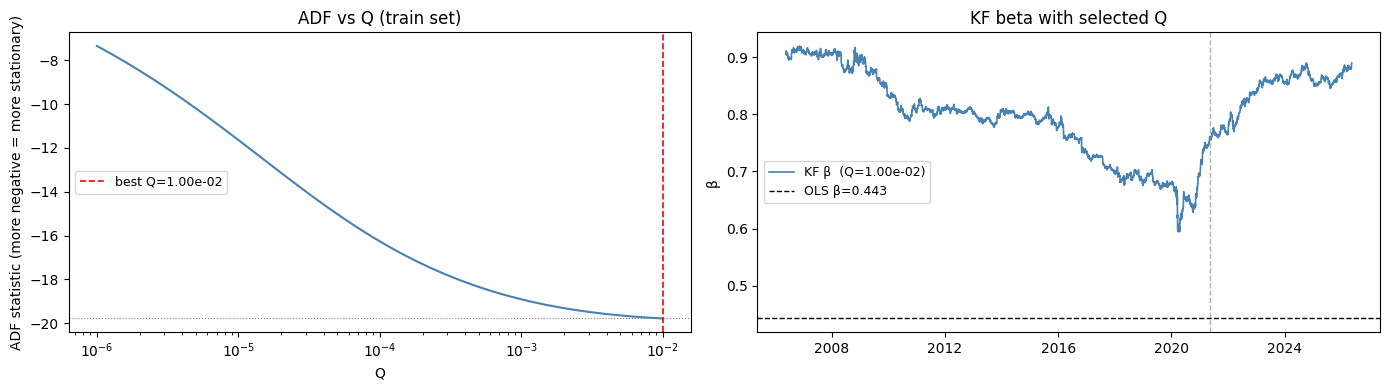

In [24]:
from statsmodels.tsa.stattools import adfuller

# search over Q on a log scale, evaluate ADF on train spread only
Q_grid = np.logspace(-6, -2, 40)
adf_stats = []

for q in Q_grid:
    b, icp, sp = kalman_beta(log_xom, log_cvx, Q_var=q)
    sp_train = sp[:train_end]
    stat, pval, _, _, _, _ = adfuller(sp_train, maxlag=10, autolag='AIC')
    adf_stats.append(stat)

adf_stats = np.array(adf_stats)
best_idx  = int(np.argmin(adf_stats))   # most negative = most stationary
best_Q    = Q_grid[best_idx]

print(f'Best Q = {best_Q:.2e}  (ADF stat = {adf_stats[best_idx]:.3f})')

# rerun with best Q
beta_kf, icp_kf, spread_kf = kalman_beta(log_xom, log_cvx, Q_var=best_Q)

# compare ADF: static OLS spread vs KF spread (both on train set)
spread_ols_train = log_xom[:train_end] - beta_ols * log_cvx[:train_end] - icp_ols
adf_ols = adfuller(spread_ols_train, maxlag=10, autolag='AIC')
adf_kf  = adfuller(spread_kf[:train_end], maxlag=10, autolag='AIC')
print(f'OLS spread  ADF stat={adf_ols[0]:.3f}  p={adf_ols[1]:.4f}')
print(f'KF  spread  ADF stat={adf_kf[0]:.3f}  p={adf_kf[1]:.4f}')

# ── Plot ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
ax.semilogx(Q_grid, adf_stats, color='steelblue', lw=1.5)
ax.axvline(best_Q, color='red', lw=1.2, ls='--', label=f'best Q={best_Q:.2e}')
ax.axhline(adf_stats[best_idx], color='gray', lw=0.8, ls=':')
ax.set_xlabel('Q'); ax.set_ylabel('ADF statistic (more negative = more stationary)')
ax.set_title('ADF vs Q (train set)')
ax.legend(fontsize=9)

ax = axes[1]
ax.plot(dates, beta_kf, color='steelblue', lw=1.2, label=f'KF β  (Q={best_Q:.2e})')
ax.axhline(beta_ols, color='black', lw=1.0, ls='--', label=f'OLS β={beta_ols:.3f}')
ax.axvline(dates[train_end], color='gray', lw=1, ls='--', alpha=0.6)
ax.set_ylabel('β'); ax.set_title('KF beta with selected Q')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

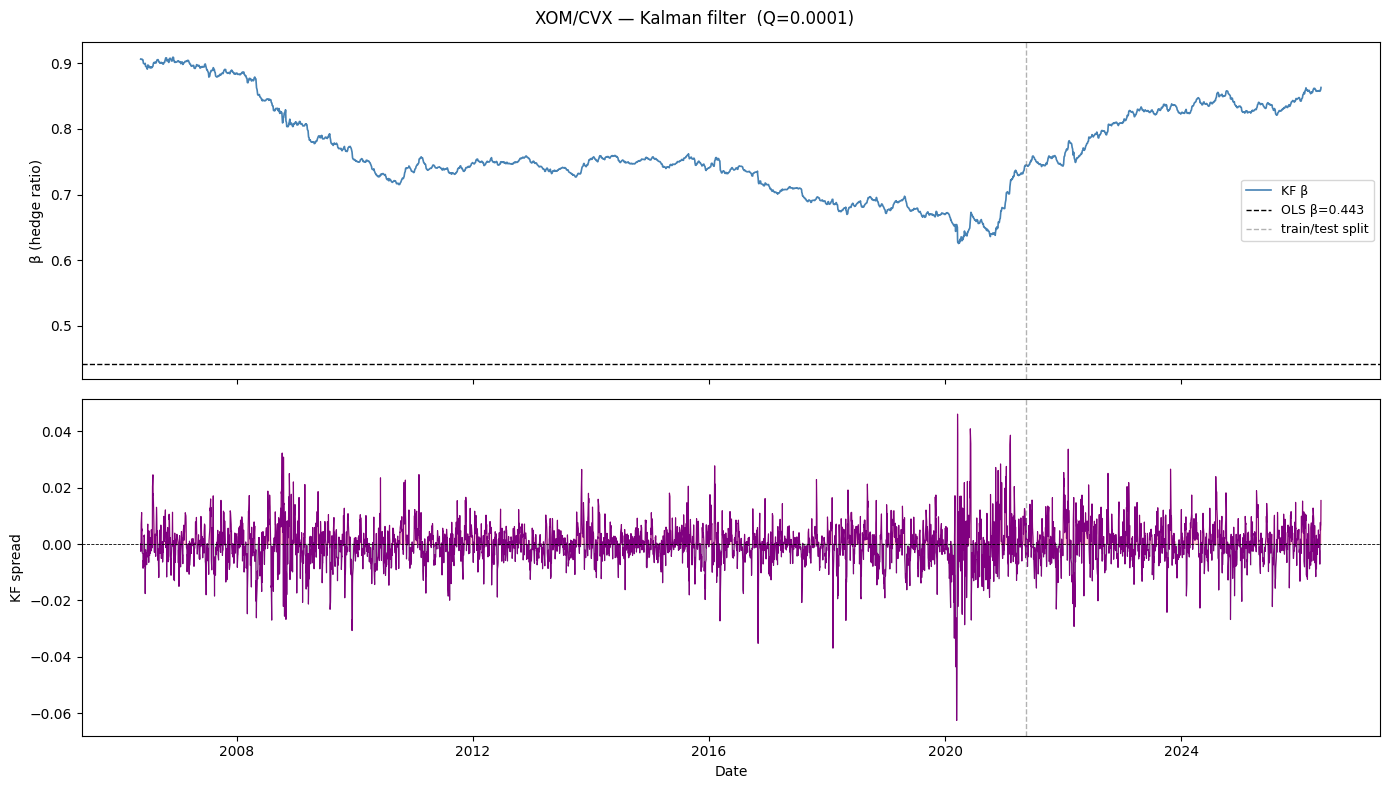

KF spread (train)  ADF stat=-16.271  p=0.0000


In [25]:
Q_CHOSEN = 1e-4
beta_kf, icp_kf, spread_kf = kalman_beta(log_xom, log_cvx, Q_var=Q_CHOSEN)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
fig.suptitle(f'XOM/CVX — Kalman filter  (Q={Q_CHOSEN})', fontsize=12)

ax = axes[0]
ax.plot(dates, beta_kf, color='steelblue', lw=1.2, label=f'KF β')
ax.axhline(beta_ols, color='black', lw=1.0, ls='--', label=f'OLS β={beta_ols:.3f}')
ax.axvline(dates[train_end], color='gray', lw=1, ls='--', alpha=0.6, label='train/test split')
ax.set_ylabel('β (hedge ratio)')
ax.legend(fontsize=9)

ax = axes[1]
ax.plot(dates, spread_kf, color='purple', lw=0.8)
ax.axhline(0, color='black', lw=0.6, ls='--')
ax.axvline(dates[train_end], color='gray', lw=1, ls='--', alpha=0.6)
ax.fill_between(dates, spread_kf, 0, where=(spread_kf > 0), alpha=0.15, color='red')
ax.fill_between(dates, spread_kf, 0, where=(spread_kf < 0), alpha=0.15, color='green')
ax.set_ylabel('KF spread')
ax.set_xlabel('Date')

plt.tight_layout()
plt.show()

adf = adfuller(spread_kf[:train_end], maxlag=10, autolag='AIC')
print(f'KF spread (train)  ADF stat={adf[0]:.3f}  p={adf[1]:.4f}')

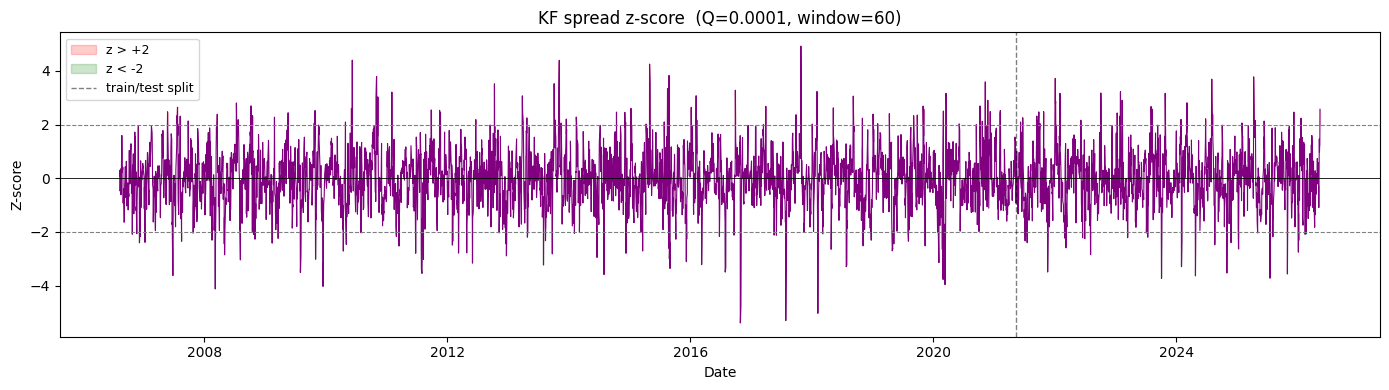

In [26]:
WINDOW = 60
s = pd.Series(spread_kf)
z_kf = (s - s.rolling(WINDOW).mean()) / s.rolling(WINDOW).std().clip(lower=1e-8)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(dates, z_kf, color='purple', lw=0.8)
ax.axhline( 2, color='gray', lw=0.8, ls='--')
ax.axhline(-2, color='gray', lw=0.8, ls='--')
ax.axhline( 0, color='black', lw=0.6, ls='-')
ax.fill_between(dates, z_kf,  2, where=(z_kf >  2), alpha=0.2, color='red',   label='z > +2')
ax.fill_between(dates, z_kf, -2, where=(z_kf < -2), alpha=0.2, color='green', label='z < -2')
ax.axvline(dates[train_end], color='black', lw=1, ls='--', alpha=0.5, label='train/test split')
ax.set_ylabel('Z-score')
ax.set_xlabel('Date')
ax.set_title(f'KF spread z-score  (Q={Q_CHOSEN}, window={WINDOW})')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

In [27]:
from env_kf import PairTradingEnv as KFEnv

def run_threshold(prices, z, beta, entry_z, exit_z, t_start, t_end, tc=0.0001):
    env = KFEnv(prices, tc=tc, episode_len=t_end - t_start)
    env.reset(t_start=t_start)
    wealth = [env._wealth()]

    for t in range(t_start, t_end):
        pos = env._pos
        z_t = z[t]

        if np.isnan(z_t):
            direction_idx = {0: 0, 1: 1, -1: 2}[pos]   # stay wherever we are
        elif pos == 0:
            if   z_t < -entry_z: direction_idx = 1      # enter long
            elif z_t >  entry_z: direction_idx = 2      # enter short
            else:                direction_idx = 0      # stay flat
        elif pos == 1:
            direction_idx = 0 if z_t > -exit_z else 1  # exit or stay long
        else:  # pos == -1
            direction_idx = 0 if z_t <  exit_z else 2  # exit or stay short

        env.step((direction_idx, beta[t]))
        wealth.append(env._wealth())

    if env._pos != 0:
        env.step((0, 0.0))
        wealth[-1] = env._wealth()

    return np.array(wealth)


def sharpe(W):
    r = np.diff(W) / W[:-1]
    return r.mean() / (r.std() + 1e-10) * np.sqrt(252)

def ann_ret(W):
    return (W[-1] / W[0]) ** (252 / (len(W) - 1)) - 1


# ── Grid search on train set only ─────────────────────────────────────────
z_arr    = z_kf.values
entry_grid = [1.0, 1.5, 2.0, 2.5, 3.0]
exit_grid  = [0.0, 0.25, 0.5, 0.75, 1.0]

results = {}
for en in entry_grid:
    for ex in exit_grid:
        if ex >= en:
            continue
        W = run_threshold(prices, z_arr, beta_kf, en, ex, t_start=0, t_end=train_end)
        results[(en, ex)] = (sharpe(W), ann_ret(W), W)

ranked = sorted(results.items(), key=lambda x: x[1][0], reverse=True)

print(f"{'entry_z':>8} {'exit_z':>7}  {'Sharpe':>8}  {'Ann ret':>9}")
print('-' * 40)
for (en, ex), (sr, ar, _) in ranked:
    print(f'{en:8.2f} {ex:7.2f}  {sr:8.3f}  {ar*100:+8.2f}%')

best_key = ranked[0][0]
print(f'\nBest: entry_z={best_key[0]}  exit_z={best_key[1]}')

 entry_z  exit_z    Sharpe    Ann ret
----------------------------------------
    3.00    0.00     0.372     +0.98%
    2.00    0.00     0.369     +1.41%
    3.00    0.25     0.357     +0.87%
    2.00    0.25     0.323     +1.14%
    2.50    0.00     0.260     +0.82%
    3.00    0.50     0.254     +0.60%
    1.00    0.50     0.243     +1.19%
    1.50    0.25     0.241     +1.03%
    2.00    0.50     0.230     +0.76%
    3.00    1.00     0.216     +0.48%
    3.00    0.75     0.197     +0.45%
    1.00    0.25     0.194     +0.96%
    1.50    0.00     0.194     +0.83%
    2.50    0.25     0.180     +0.52%
    1.00    0.75     0.164     +0.72%
    1.50    0.50     0.159     +0.61%
    2.50    0.75     0.159     +0.42%
    2.50    1.00     0.152     +0.38%
    2.00    0.75     0.140     +0.42%
    2.00    1.00     0.132     +0.38%
    2.50    0.50     0.102     +0.26%
    1.50    0.75     0.043     +0.09%
    1.50    1.00    -0.002     -0.09%
    1.00    0.00    -0.010     -0.25%

Best: en

Best params:  entry_z=3.0  exit_z=0.0
Train  Sharpe=0.372  ann=+0.98%
Test   Sharpe=-0.136  ann=-0.32%


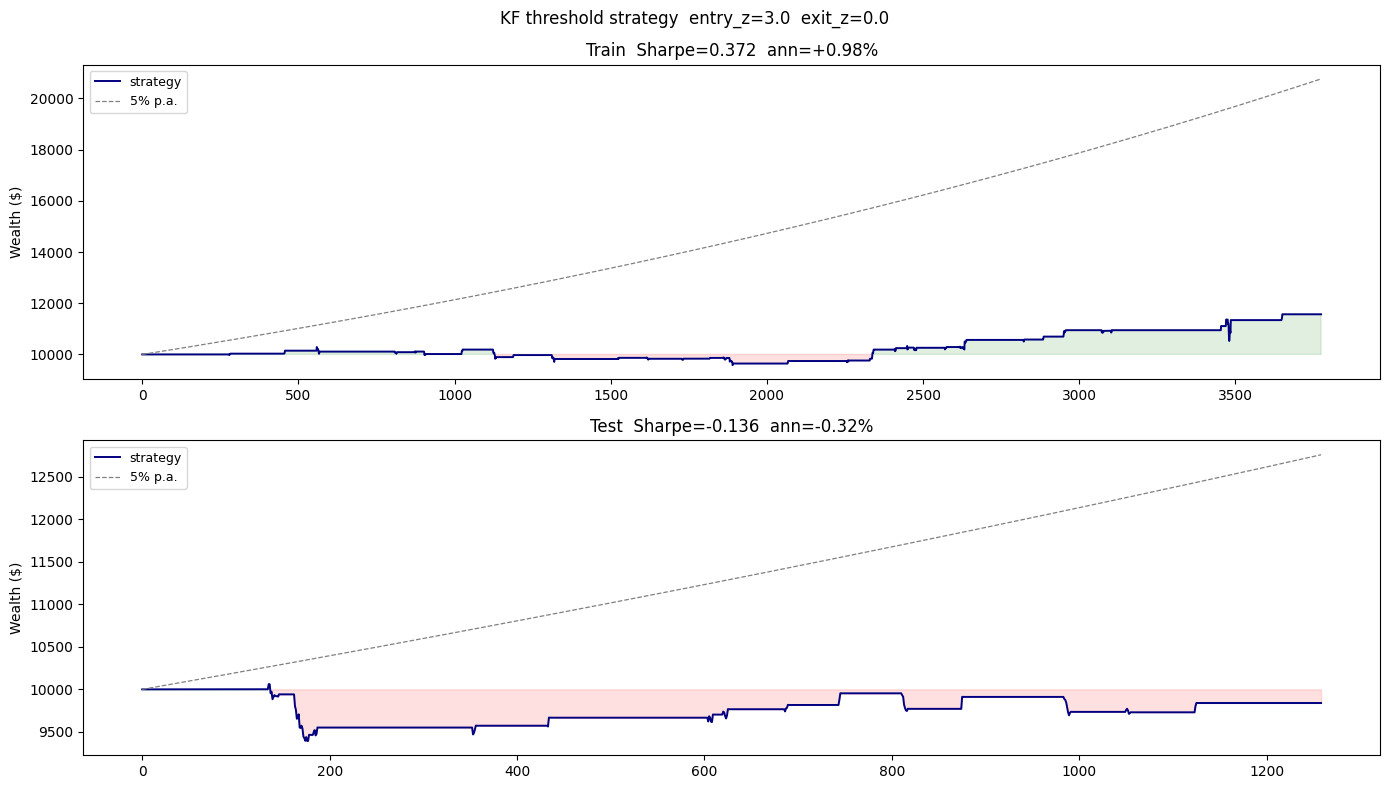

In [28]:
en, ex = best_key
W_train = run_threshold(prices, z_arr, beta_kf, en, ex, t_start=0,         t_end=train_end)
W_test  = run_threshold(prices, z_arr, beta_kf, en, ex, t_start=train_end, t_end=N)

print(f'Best params:  entry_z={en}  exit_z={ex}')
print(f'Train  Sharpe={sharpe(W_train):.3f}  ann={ann_ret(W_train)*100:+.2f}%')
print(f'Test   Sharpe={sharpe(W_test):.3f}  ann={ann_ret(W_test)*100:+.2f}%')

_RF = (1.05) ** (1/252) - 1

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=False)
fig.suptitle(f'KF threshold strategy  entry_z={en}  exit_z={ex}', fontsize=12)

for ax, W, label, t0 in [
    (axes[0], W_train, 'Train', 0),
    (axes[1], W_test,  'Test',  train_end),
]:
    t_ax = np.arange(len(W))
    bh   = W[0] * (1 + _RF) ** t_ax
    ax.plot(t_ax, W,  color='navy',  lw=1.4, label='strategy')
    ax.plot(t_ax, bh, color='gray',  lw=0.9, ls='--', label='5% p.a.')
    ax.fill_between(t_ax, W, W[0], where=(W >= W[0]), alpha=0.12, color='green')
    ax.fill_between(t_ax, W, W[0], where=(W <  W[0]), alpha=0.12, color='red')
    ax.set_title(f'{label}  Sharpe={sharpe(W):.3f}  ann={ann_ret(W)*100:+.2f}%')
    ax.set_ylabel('Wealth ($)')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

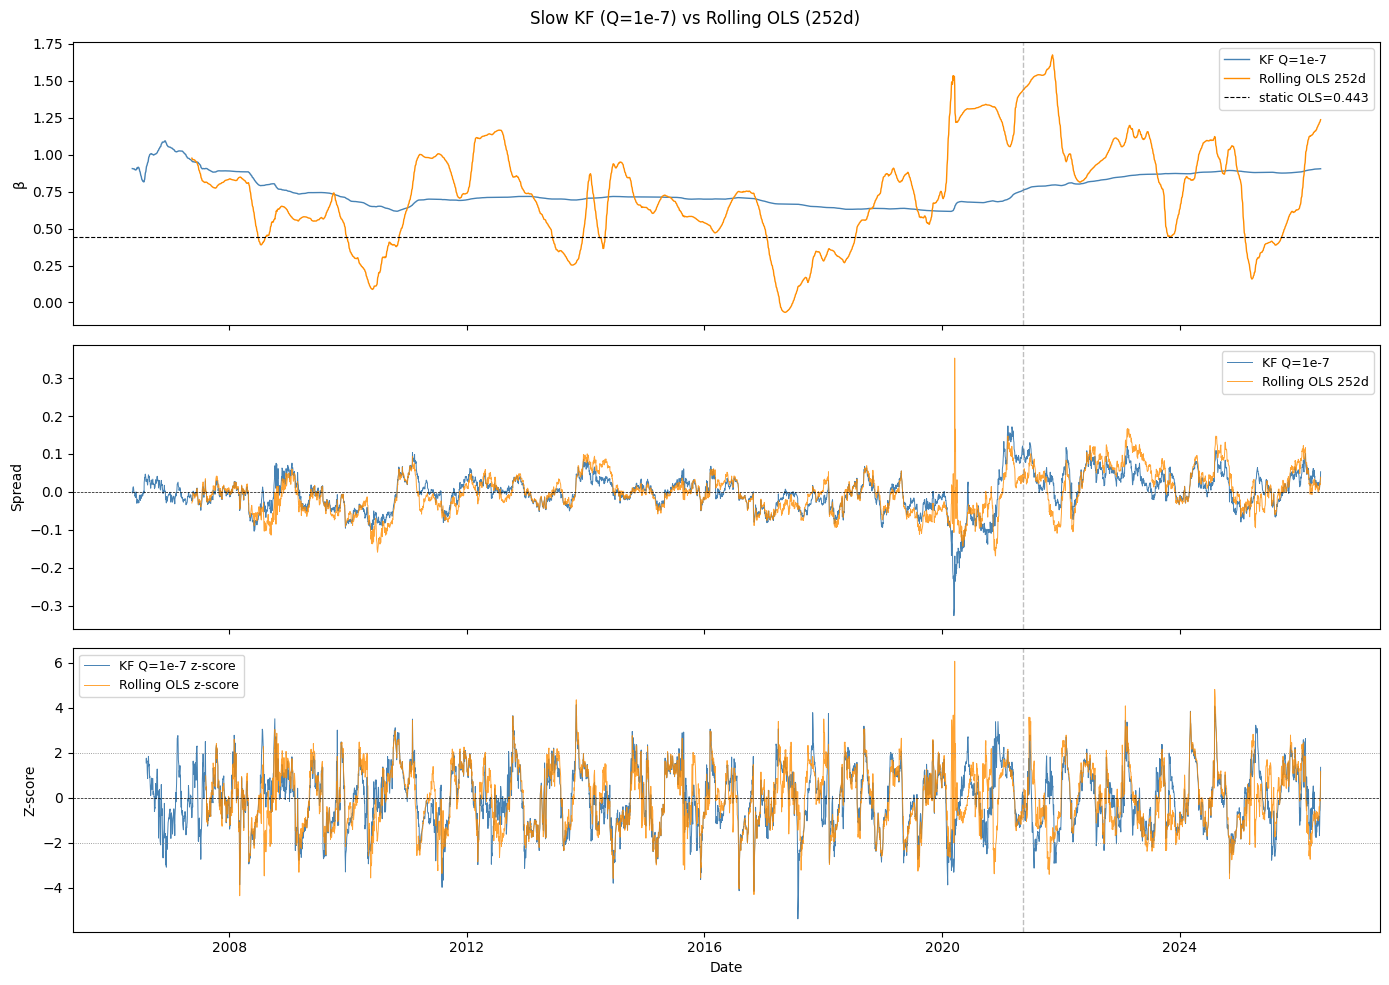

In [29]:
# ── Rolling OLS beta (252-day window) ────────────────────────────────────
OLS_WINDOW = 252

def rolling_ols(log_A, log_B, window):
    n     = len(log_A)
    betas = np.full(n, np.nan)
    icps  = np.full(n, np.nan)
    for t in range(window, n):
        A_w = log_A[t - window : t]
        B_w = log_B[t - window : t]
        X   = np.column_stack([B_w, np.ones(window)])
        c, _, _, _ = np.linalg.lstsq(X, A_w, rcond=None)
        betas[t] = c[0]
        icps[t]  = c[1]
    spread = log_A - betas * log_B - icps
    return betas, icps, spread

beta_rols, icp_rols, spread_rols = rolling_ols(log_xom, log_cvx, OLS_WINDOW)

# ── KF with Q = 1e-7 ─────────────────────────────────────────────────────
Q_SLOW = 1e-7
beta_kf7, icp_kf7, spread_kf7 = kalman_beta(log_xom, log_cvx, Q_var=Q_SLOW)

# ── Z-scores (60-day rolling) ─────────────────────────────────────────────
def rolling_z(spread, window=60):
    s = pd.Series(spread)
    return (s - s.rolling(window).mean()) / s.rolling(window).std().clip(lower=1e-8)

z_rols = rolling_z(spread_rols)
z_kf7  = rolling_z(spread_kf7)

# ── Compare betas ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
fig.suptitle('Slow KF (Q=1e-7) vs Rolling OLS (252d)', fontsize=12)

ax = axes[0]
ax.plot(dates, beta_kf7,  color='steelblue',  lw=1.0, label='KF Q=1e-7')
ax.plot(dates, beta_rols, color='darkorange', lw=1.0, label='Rolling OLS 252d')
ax.axhline(beta_ols, color='black', lw=0.8, ls='--', label=f'static OLS={beta_ols:.3f}')
ax.axvline(dates[train_end], color='gray', lw=1, ls='--', alpha=0.5)
ax.set_ylabel('β'); ax.legend(fontsize=9)

ax = axes[1]
ax.plot(dates, spread_kf7,  color='steelblue',  lw=0.7, label='KF Q=1e-7')
ax.plot(dates, spread_rols, color='darkorange', lw=0.7, alpha=0.8, label='Rolling OLS 252d')
ax.axhline(0, color='black', lw=0.5, ls='--')
ax.axvline(dates[train_end], color='gray', lw=1, ls='--', alpha=0.5)
ax.set_ylabel('Spread'); ax.legend(fontsize=9)

ax = axes[2]
ax.plot(dates, z_kf7,  color='steelblue',  lw=0.7, label='KF Q=1e-7 z-score')
ax.plot(dates, z_rols, color='darkorange', lw=0.7, alpha=0.8, label='Rolling OLS z-score')
ax.axhline(2, color='gray', lw=0.6, ls=':'); ax.axhline(-2, color='gray', lw=0.6, ls=':')
ax.axhline(0, color='black', lw=0.5, ls='--')
ax.axvline(dates[train_end], color='gray', lw=1, ls='--', alpha=0.5)
ax.set_ylabel('Z-score'); ax.legend(fontsize=9); ax.set_xlabel('Date')

plt.tight_layout(); plt.show()


KF Q=1e-7
  Best train:  entry=3.00  exit=2.75  Sharpe=0.295  ann=+0.51%
  OOS test:    Sharpe=-0.348  ann=-0.48%


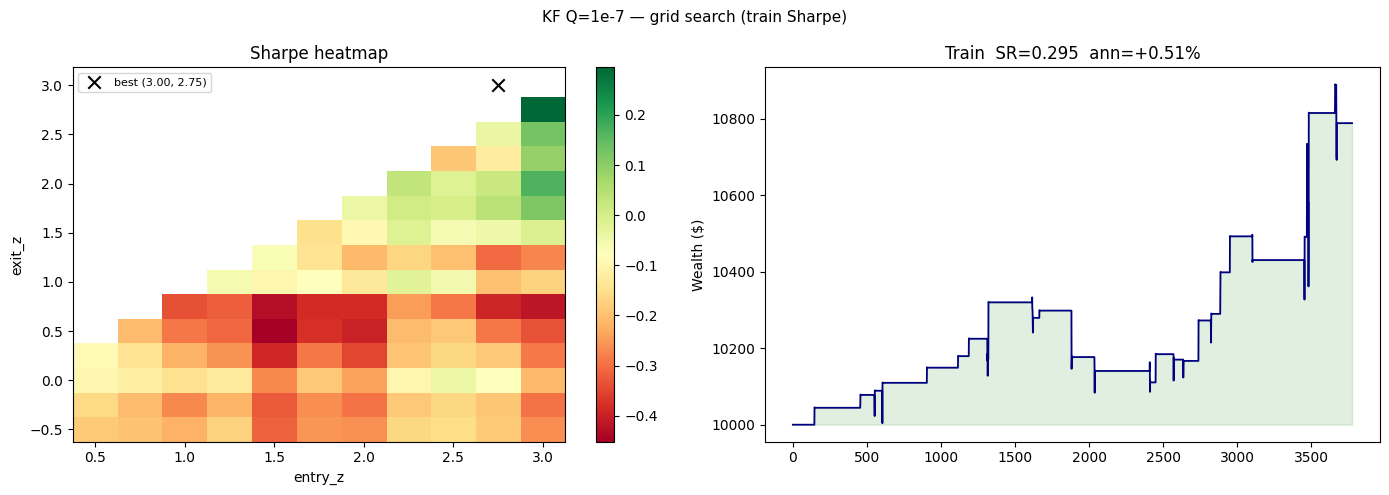


Rolling OLS 252d
  Best train:  entry=1.75  exit=1.50  Sharpe=0.617  ann=+3.43%
  OOS test:    Sharpe=-0.179  ann=-0.96%


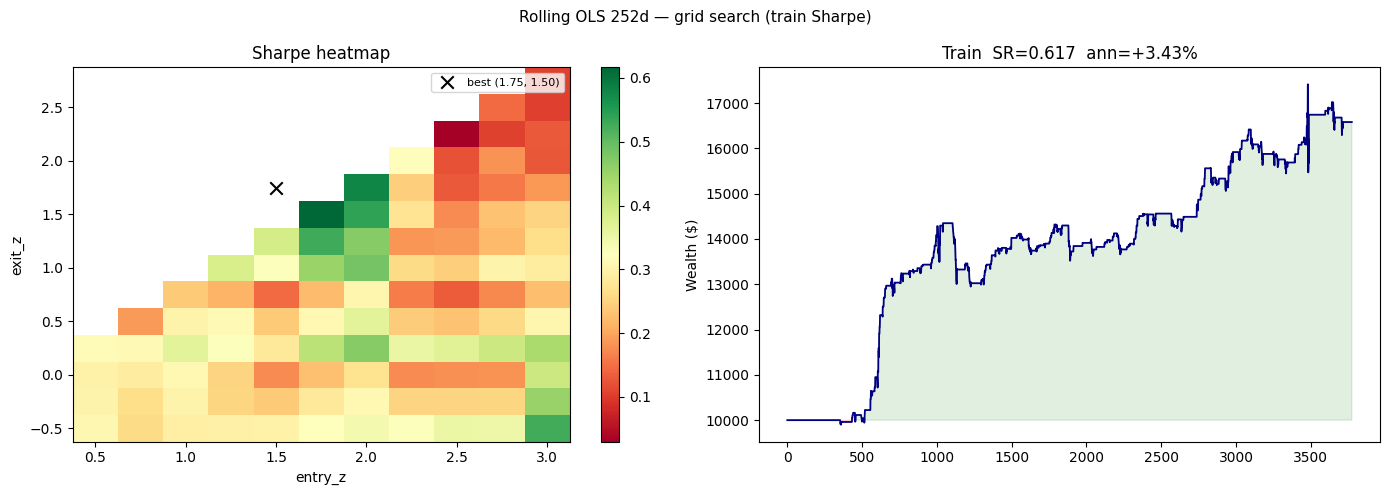

In [30]:
# ── Grid search ──────────────────────────────────────────────────────────
entry_grid = np.arange(0.5, 3.25, 0.25)
exit_grid  = np.arange(-0.5, 3.0,  0.25)

def grid_search(z_arr, beta_arr, label):
    best_sr, best_params, best_W = -np.inf, None, None
    # store for heatmap
    en_vals = []; ex_vals = []; sr_vals = []

    for en in entry_grid:
        for ex in exit_grid:
            if ex >= en:
                continue
            W = run_threshold(prices, z_arr, beta_arr,
                              en, ex, t_start=0, t_end=train_end)
            sr = sharpe(W)
            en_vals.append(en); ex_vals.append(ex); sr_vals.append(sr)
            if sr > best_sr:
                best_sr, best_params, best_W = sr, (en, ex), W

    print(f'\n{label}')
    print(f'  Best train:  entry={best_params[0]:.2f}  exit={best_params[1]:.2f}  '
          f'Sharpe={best_sr:.3f}  ann={ann_ret(best_W)*100:+.2f}%')

    W_test = run_threshold(prices, z_arr, beta_arr,
                           *best_params, t_start=train_end, t_end=N)
    print(f'  OOS test:    Sharpe={sharpe(W_test):.3f}  ann={ann_ret(W_test)*100:+.2f}%')

    # heatmap
    en_u = sorted(set(en_vals)); ex_u = sorted(set(ex_vals))
    heat = np.full((len(ex_u), len(en_u)), np.nan)
    for en, ex, sr in zip(en_vals, ex_vals, sr_vals):
        i = ex_u.index(ex); j = en_u.index(en)
        heat[i, j] = sr

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'{label} — grid search (train Sharpe)', fontsize=11)

    im = axes[0].imshow(heat, aspect='auto', origin='lower',
                        extent=[en_u[0]-0.125, en_u[-1]+0.125,
                                ex_u[0]-0.125, ex_u[-1]+0.125],
                        cmap='RdYlGn')
    axes[0].set_xlabel('entry_z'); axes[0].set_ylabel('exit_z')
    axes[0].set_title('Sharpe heatmap')
    plt.colorbar(im, ax=axes[0])
    axes[0].scatter(*best_params[::-1], color='black', s=80, marker='x', zorder=5,
                    label=f'best ({best_params[0]:.2f}, {best_params[1]:.2f})')
    axes[0].legend(fontsize=8)

    for ax, W, split_label in [
        (axes[1], best_W,  f'Train  SR={sharpe(best_W):.3f}  ann={ann_ret(best_W)*100:+.2f}%'),
    ]:
        t_ax = np.arange(len(W))
        ax.plot(t_ax, W, color='navy', lw=1.3)
        ax.fill_between(t_ax, W, W[0], where=(W>=W[0]), alpha=0.12, color='green')
        ax.fill_between(t_ax, W, W[0], where=(W< W[0]), alpha=0.12, color='red')
        ax.set_title(split_label); ax.set_ylabel('Wealth ($)')

    plt.tight_layout(); plt.show()

    return best_params, W_test

best_kf7,  W_test_kf7  = grid_search(z_kf7.values,  beta_kf7,  'KF Q=1e-7')
best_rols, W_test_rols = grid_search(z_rols.values, beta_rols, 'Rolling OLS 252d')

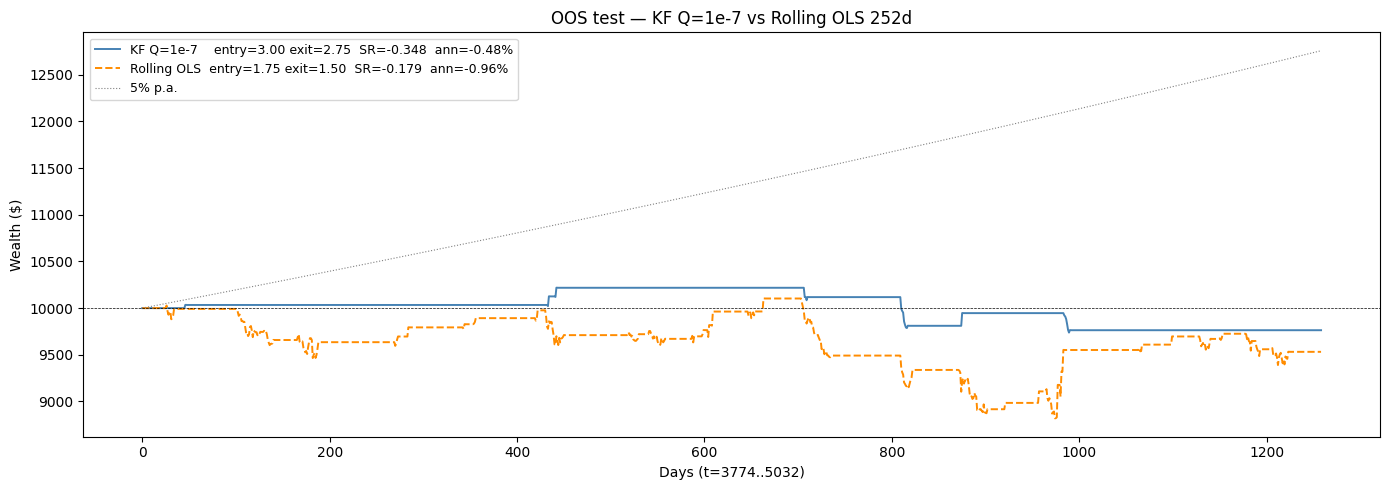

In [31]:
# ── OOS comparison ────────────────────────────────────────────────────────
_RF = (1.05) ** (1/252) - 1
fig, ax = plt.subplots(figsize=(14, 5))
t_ax = np.arange(len(W_test_kf7))

ax.plot(t_ax, W_test_kf7,  color="steelblue",  lw=1.4,
        label=f"KF Q=1e-7    entry={best_kf7[0]:.2f} exit={best_kf7[1]:.2f}  "
               f"SR={sharpe(W_test_kf7):.3f}  ann={ann_ret(W_test_kf7)*100:+.2f}%")
ax.plot(t_ax, W_test_rols, color="darkorange", lw=1.4, ls="--",
        label=f"Rolling OLS  entry={best_rols[0]:.2f} exit={best_rols[1]:.2f}  "
               f"SR={sharpe(W_test_rols):.3f}  ann={ann_ret(W_test_rols)*100:+.2f}%")
ax.plot(t_ax, W_test_kf7[0] * (1 + _RF) ** t_ax,
        color="gray", lw=0.8, ls=":", label="5% p.a.")
ax.axhline(W_test_kf7[0], color="black", lw=0.5, ls="--")
ax.set_title("OOS test — KF Q=1e-7 vs Rolling OLS 252d")
ax.set_ylabel("Wealth ($)"); ax.set_xlabel(f"Days (t={train_end}..{N})")
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

In [32]:
class PairBacktester:
    """
    Pairs trading backtester with dynamic beta at entry.
    Beta is locked at entry time and not rehedged until exit.

    Logic:
      - Flat:  enter long  when z < -entry_z
               enter short when z >  entry_z
      - Long:  exit when z > -exit_z  (spread has reverted toward zero)
      - Short: exit when z <  exit_z
    """

    def __init__(self, prices, initial_wealth=10_000.0, tc=0.0001):
        self.prices         = prices.astype(np.float64)
        self.N              = prices.shape[1]
        self.initial_wealth = float(initial_wealth)
        self.tc             = float(tc)

    def run(self, z, beta, entry_z, exit_z):
        cash   = self.initial_wealth
        shares = np.zeros(2)
        pos    = 0
        wealth = np.empty(self.N)

        def w(t):
            return cash + shares @ self.prices[:, t]

        def enter(t, direction, b):
            nonlocal cash, shares, pos
            p0, p1 = self.prices[0, t], self.prices[1, t]
            C  = w(t)
            d0 = C / (1.0 + b)
            d1 = b * C / (1.0 + b)
            shares[0] =  direction * d0 / p0
            shares[1] = -direction * d1 / p1
            cash += direction * (d1 - d0)
            cash -= self.tc * (d0 + d1)
            pos = direction

        def exit_(t):
            nonlocal cash, shares, pos
            p0, p1   = self.prices[0, t], self.prices[1, t]
            notional = abs(shares[0]) * p0 + abs(shares[1]) * p1
            cash  = w(t) - self.tc * notional
            shares[:] = 0.0
            pos = 0

        for t in range(self.N):
            if np.isnan(z[t]):
                wealth[t] = w(t)
                continue

            if pos == 0:
                if   z[t] < -entry_z: enter(t,  1, beta[t])
                elif z[t] >  entry_z: enter(t, -1, beta[t])
            elif pos == 1:
                if z[t] > -exit_z:   exit_(t)
            elif pos == -1:
                if z[t] <  exit_z:   exit_(t)

            wealth[t] = w(t)

        if pos != 0:
            exit_(self.N - 1)
            wealth[-1] = w(self.N - 1)

        return wealth

bt = PairBacktester(prices)
print('PairBacktester ready.')

PairBacktester ready.


OLS beta=0.4427  intercept=2.0421


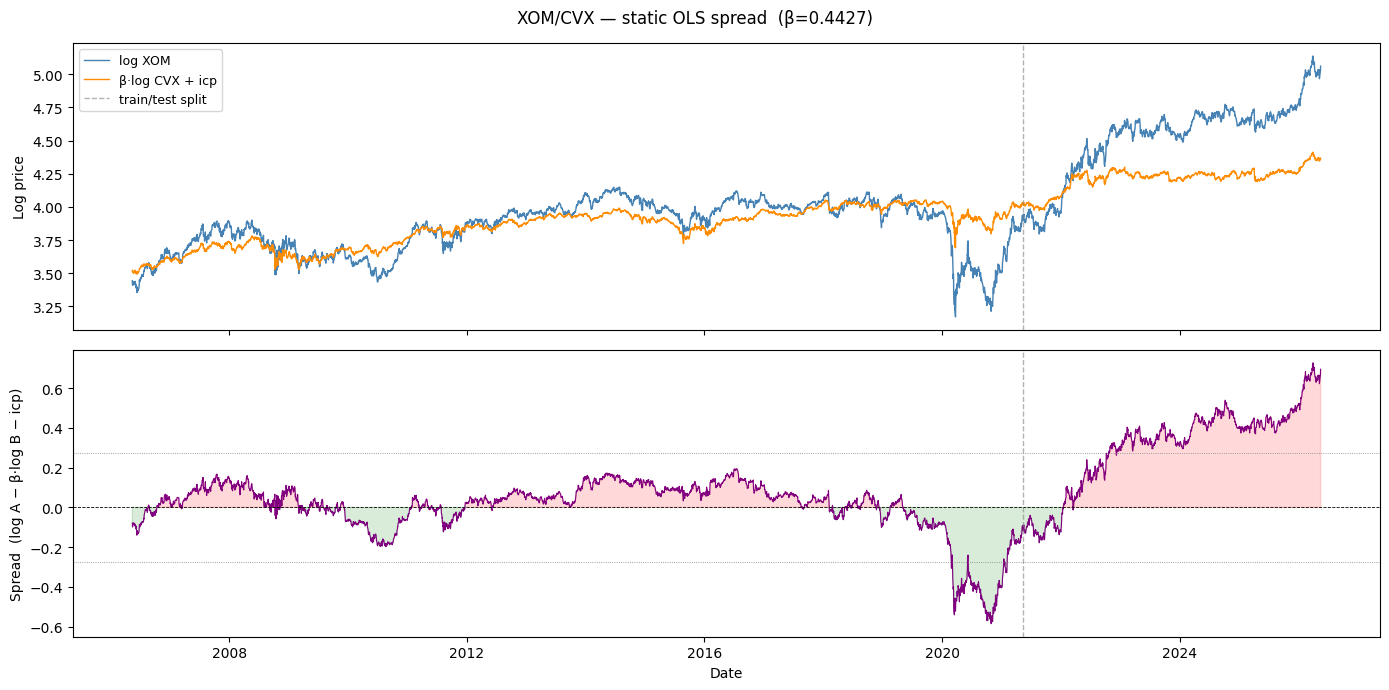

In [33]:
# ── Static OLS beta on full train set ────────────────────────────────────
X_ols = np.column_stack([log_cvx[:train_end], np.ones(train_end)])
c_ols, _, _, _ = np.linalg.lstsq(X_ols, log_xom[:train_end], rcond=None)
beta_ols, icp_ols = float(c_ols[0]), float(c_ols[1])

spread_ols = log_xom - beta_ols * log_cvx - icp_ols

print(f'OLS beta={beta_ols:.4f}  intercept={icp_ols:.4f}')

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
fig.suptitle(f'XOM/CVX — static OLS spread  (β={beta_ols:.4f})', fontsize=12)

ax = axes[0]
ax.plot(dates, log_xom, color='steelblue',  lw=1.0, label=f'log {labels[0]}')
ax.plot(dates, log_cvx * beta_ols + icp_ols, color='darkorange', lw=1.0,
        label=f'β·log {labels[1]} + icp')
ax.axvline(dates[train_end], color='gray', lw=1, ls='--', alpha=0.6, label='train/test split')
ax.set_ylabel('Log price'); ax.legend(fontsize=9)

ax = axes[1]
ax.plot(dates, spread_ols, color='purple', lw=0.8)
ax.axhline(0, color='black', lw=0.6, ls='--')
ax.axhline( spread_ols[:train_end].std() * 2, color='gray', lw=0.6, ls=':')
ax.axhline(-spread_ols[:train_end].std() * 2, color='gray', lw=0.6, ls=':')
ax.axvline(dates[train_end], color='gray', lw=1, ls='--', alpha=0.6)
ax.fill_between(dates, spread_ols, 0, where=(spread_ols > 0), alpha=0.15, color='red')
ax.fill_between(dates, spread_ols, 0, where=(spread_ols < 0), alpha=0.15, color='green')
ax.set_ylabel('Spread  (log A − β·log B − icp)'); ax.set_xlabel('Date')

plt.tight_layout(); plt.show()

Refit points: 38
Beta range:   0.100 – 3.000
HL range:     4.3 – 43.3 days


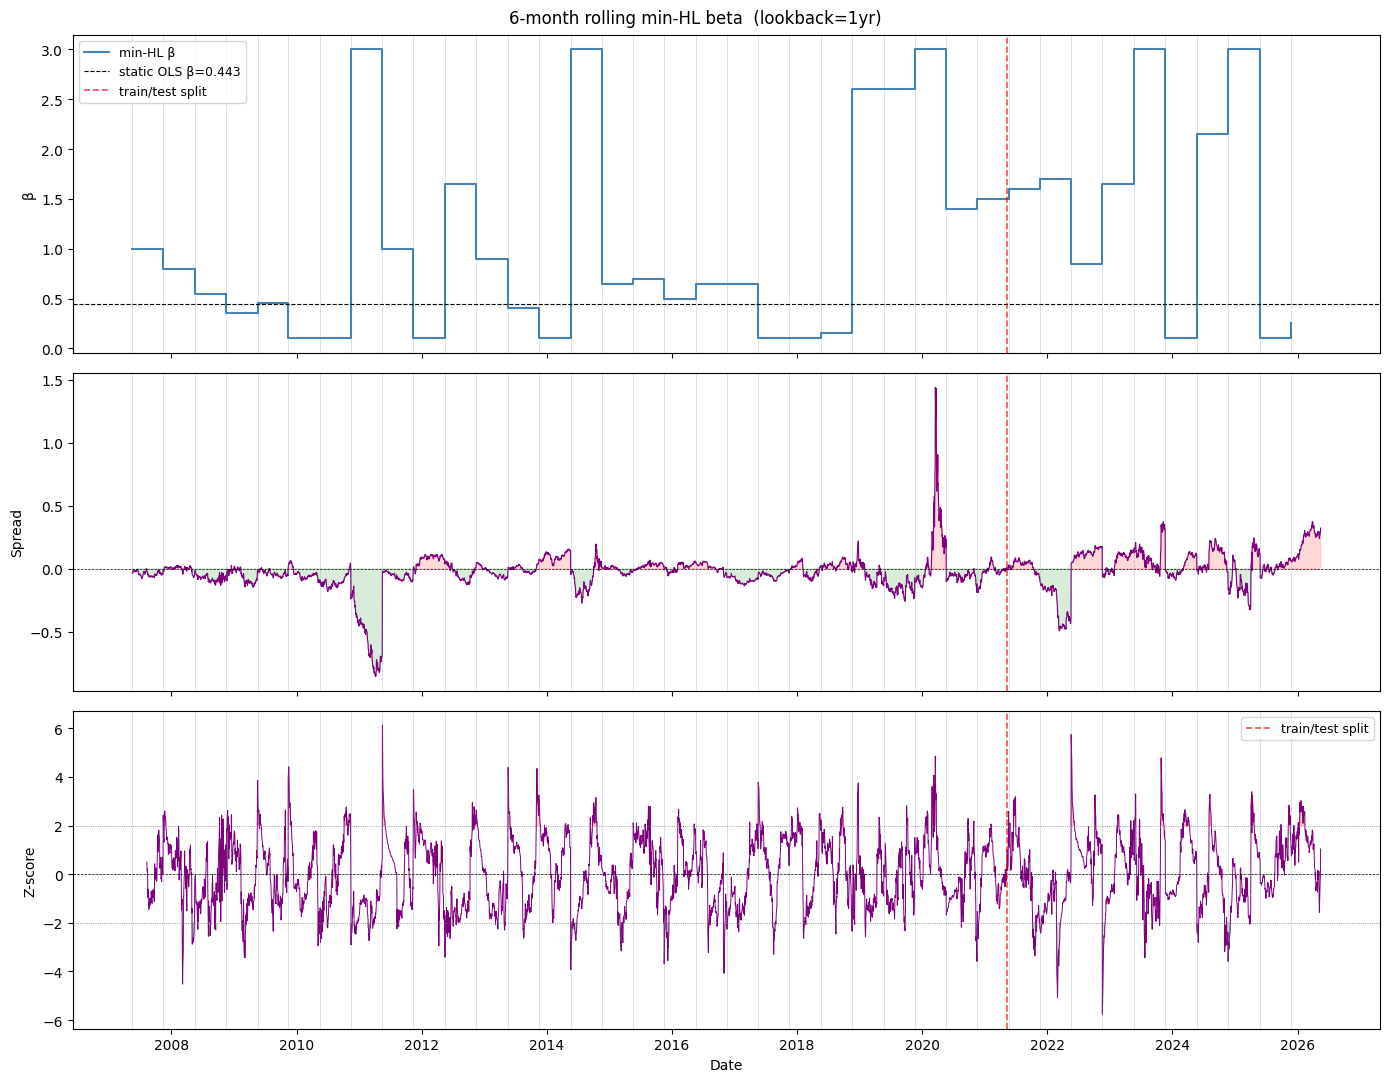

In [34]:
# ── 6-month rolling beta via minimum half-life ────────────────────────────
# Every 126 days: fit beta on past 252 days that minimises AR(1) half-life.
# Half-life of AR(1)  s[t] = a + phi*s[t-1] + e  is  -log(2)/log(|phi|).

REFIT_FREQ  = 126   # ~6 months
HL_LOOKBACK = 252   # 1 year
BETA_GRID   = np.arange(0.1, 3.01, 0.05)

def min_hl_beta(log_A_win, log_B_win, grid):
    """Return (beta, half_life) minimising AR(1) HL over the window."""
    best_beta, best_hl = None, np.inf
    for b in grid:
        sp   = log_A_win - b * log_B_win
        y    = sp[1:]; X = np.column_stack([np.ones(len(y)), sp[:-1]])
        c, _, _, _ = np.linalg.lstsq(X, y, rcond=None)
        phi  = float(c[1])
        if phi <= 0 or phi >= 1:
            continue
        hl = -np.log(2) / np.log(phi)
        if hl < best_hl:
            best_hl, best_beta = hl, b
    return best_beta, best_hl

# build piecewise-constant beta and intercept arrays
beta_hl = np.full(N, np.nan)
icp_hl  = np.full(N, np.nan)
refit_t    = []   # time indices where we refit
refit_beta = []
refit_hl   = []

t = HL_LOOKBACK
while t < N:
    A_w = log_xom[t - HL_LOOKBACK : t]
    B_w = log_cvx[t - HL_LOOKBACK : t]
    b, hl = min_hl_beta(A_w, B_w, BETA_GRID)
    if b is None:
        t += REFIT_FREQ; continue
    icp = float((A_w - b * B_w).mean())
    end = min(t + REFIT_FREQ, N)
    beta_hl[t:end] = b
    icp_hl[t:end]  = icp
    refit_t.append(t)
    refit_beta.append(b)
    refit_hl.append(hl)
    t += REFIT_FREQ

spread_hl = log_xom - beta_hl * log_cvx - icp_hl

print(f'Refit points: {len(refit_t)}')
print(f'Beta range:   {min(refit_beta):.3f} – {max(refit_beta):.3f}')
print(f'HL range:     {min(refit_hl):.1f} – {max(refit_hl):.1f} days')

# ── Plot ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True)
fig.suptitle('6-month rolling min-HL beta  (lookback=1yr)', fontsize=12)

ax = axes[0]
ax.step(dates[refit_t], refit_beta, where='post', color='steelblue', lw=1.5, label='min-HL β')
ax.axhline(beta_ols, color='black', lw=0.8, ls='--', label=f'static OLS β={beta_ols:.3f}')
for rt in refit_t:
    ax.axvline(dates[rt], color='steelblue', lw=0.5, alpha=0.3)
ax.axvline(dates[train_end], color='red', lw=1.2, ls='--', alpha=0.7, label='train/test split')
ax.set_ylabel('β'); ax.legend(fontsize=9)

ax = axes[1]
ax.plot(dates, spread_hl, color='purple', lw=0.8)
ax.axhline(0, color='black', lw=0.5, ls='--')
for rt in refit_t:
    ax.axvline(dates[rt], color='steelblue', lw=0.5, alpha=0.3)
ax.axvline(dates[train_end], color='red', lw=1.2, ls='--', alpha=0.7)
ax.fill_between(dates, spread_hl, 0, where=(~np.isnan(spread_hl)) & (spread_hl > 0), alpha=0.15, color='red')
ax.fill_between(dates, spread_hl, 0, where=(~np.isnan(spread_hl)) & (spread_hl < 0), alpha=0.15, color='green')
ax.set_ylabel('Spread')

z_hl = rolling_z(spread_hl)
ax = axes[2]
ax.plot(dates, z_hl, color='purple', lw=0.7)
ax.axhline( 2, color='gray', lw=0.6, ls=':')
ax.axhline(-2, color='gray', lw=0.6, ls=':')
ax.axhline( 0, color='black', lw=0.5, ls='--')
for rt in refit_t:
    ax.axvline(dates[rt], color='steelblue', lw=0.5, alpha=0.3)
ax.axvline(dates[train_end], color='red', lw=1.2, ls='--', alpha=0.7, label='train/test split')
ax.fill_between(dates, z_hl,  2, where=(~np.isnan(z_hl)) & (z_hl >  2), alpha=0.2, color='red')
ax.fill_between(dates, z_hl, -2, where=(~np.isnan(z_hl)) & (z_hl < -2), alpha=0.2, color='green')
ax.set_ylabel('Z-score'); ax.set_xlabel('Date'); ax.legend(fontsize=9)

plt.tight_layout(); plt.show()


Min-HL rolling beta — grid search results
  Best train:  entry=1.75  exit=-0.50  Sharpe=0.429  ann=+4.33%
  OOS test:    Sharpe=-0.483  ann=-8.77%


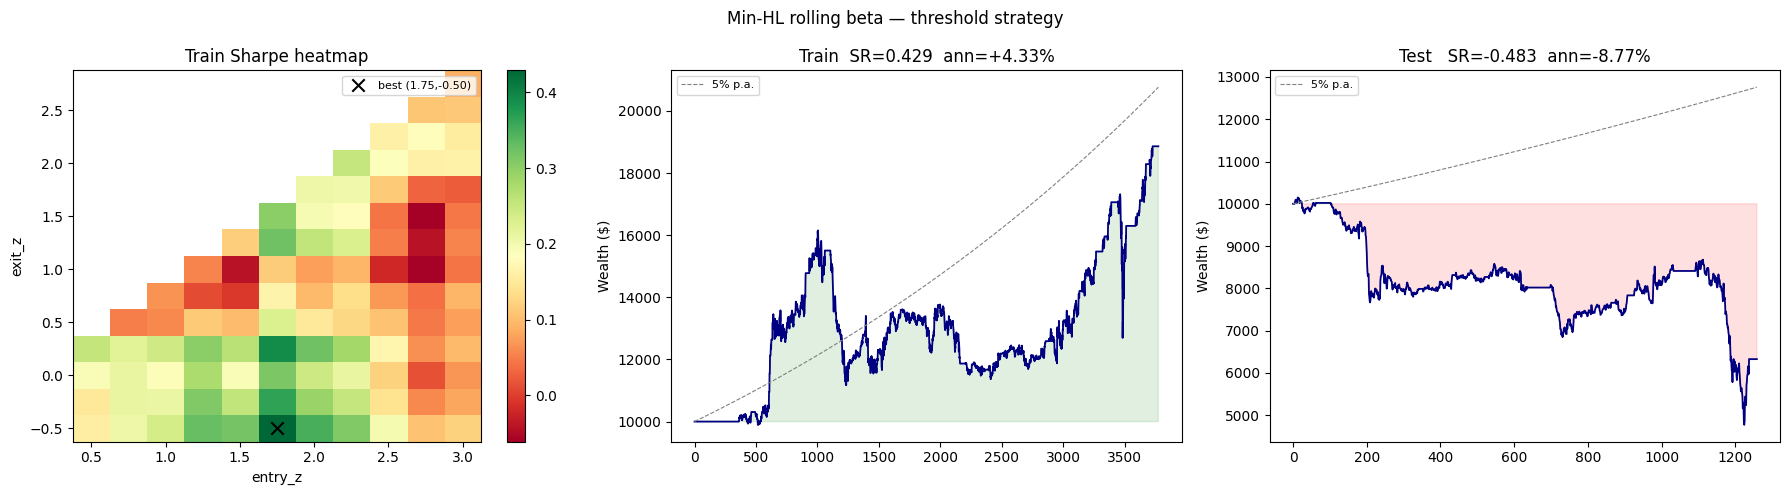

In [35]:
# ── Grid search on min-HL rolling spread ──────────────────────────────────
# Use beta_hl (piecewise-constant) as the dynamic beta for run_threshold.
# NaNs in the first HL_LOOKBACK days are handled inside run_threshold already.

entry_grid = np.arange(0.5, 3.25, 0.25)
exit_grid  = np.arange(-0.5, 3.0,  0.25)

best_sr, best_params, best_W_train = -np.inf, None, None
en_vals = []; ex_vals = []; sr_vals = []

z_hl_arr = z_hl.values

for en in entry_grid:
    for ex in exit_grid:
        if ex >= en:
            continue
        W = run_threshold(prices, z_hl_arr, beta_hl,
                          en, ex, t_start=0, t_end=train_end)
        sr = sharpe(W)
        en_vals.append(en); ex_vals.append(ex); sr_vals.append(sr)
        if sr > best_sr:
            best_sr, best_params, best_W_train = sr, (en, ex), W

W_test_hl = run_threshold(prices, z_hl_arr, beta_hl,
                          *best_params, t_start=train_end, t_end=N)

print(f'Min-HL rolling beta — grid search results')
print(f'  Best train:  entry={best_params[0]:.2f}  exit={best_params[1]:.2f}  '
      f'Sharpe={best_sr:.3f}  ann={ann_ret(best_W_train)*100:+.2f}%')
print(f'  OOS test:    Sharpe={sharpe(W_test_hl):.3f}  ann={ann_ret(W_test_hl)*100:+.2f}%')

# heatmap
en_u = sorted(set(en_vals)); ex_u = sorted(set(ex_vals))
heat = np.full((len(ex_u), len(en_u)), np.nan)
for en, ex, sr in zip(en_vals, ex_vals, sr_vals):
    heat[ex_u.index(ex), en_u.index(en)] = sr

_RF = (1.05) ** (1/252) - 1
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Min-HL rolling beta — threshold strategy', fontsize=12)

im = axes[0].imshow(heat, aspect='auto', origin='lower', cmap='RdYlGn',
                    extent=[en_u[0]-0.125, en_u[-1]+0.125,
                            ex_u[0]-0.125, ex_u[-1]+0.125])
axes[0].set_xlabel('entry_z'); axes[0].set_ylabel('exit_z')
axes[0].set_title('Train Sharpe heatmap')
plt.colorbar(im, ax=axes[0])
axes[0].scatter(best_params[0], best_params[1], color='black', s=80,
                marker='x', zorder=5, label=f'best ({best_params[0]:.2f},{best_params[1]:.2f})')
axes[0].legend(fontsize=8)

for ax, W, label in [
    (axes[1], best_W_train, f'Train  SR={sharpe(best_W_train):.3f}  ann={ann_ret(best_W_train)*100:+.2f}%'),
    (axes[2], W_test_hl,    f'Test   SR={sharpe(W_test_hl):.3f}  ann={ann_ret(W_test_hl)*100:+.2f}%'),
]:
    t_ax = np.arange(len(W))
    ax.plot(t_ax, W, color='navy', lw=1.3)
    ax.plot(t_ax, W[0]*(1+_RF)**t_ax, color='gray', lw=0.8, ls='--', label='5% p.a.')
    ax.fill_between(t_ax, W, W[0], where=(W>=W[0]), alpha=0.12, color='green')
    ax.fill_between(t_ax, W, W[0], where=(W< W[0]), alpha=0.12, color='red')
    ax.set_title(label); ax.set_ylabel('Wealth ($)'); ax.legend(fontsize=8)

plt.tight_layout(); plt.show()


Entry-beta-locked exit strategy
  Best train:  entry=1.00  exit=0.25  Sharpe=0.416  ann=+4.49%
  OOS test:    Sharpe=-0.415  ann=-5.26%


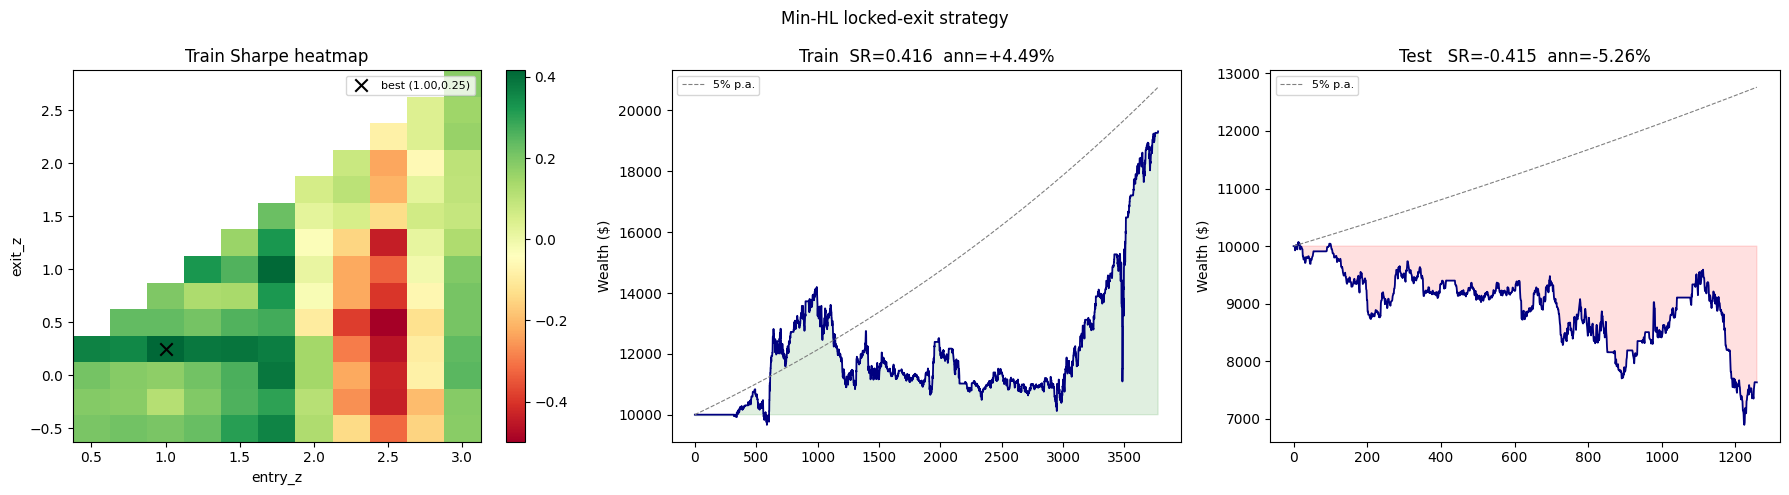

In [36]:
# ── Strategy with entry-beta-locked exit signal ────────────────────────────
#
# Entry : use current (latest refit) beta_hl z-score
# In position: track spread with the beta locked at entry,
#              compute rolling z-score from that spread for exit.
#              Stay in position until THAT z-score says to exit.
# After exit : beta_hl[t] is now the freshest refit — use it for next entry.

def run_threshold_locked(prices, log_A, log_B,
                         beta_arr, icp_arr, z_entry_arr,
                         entry_z, exit_z,
                         t_start, t_end,
                         tc=0.0001, z_window=60):
    env = KFEnv(prices, tc=tc, episode_len=t_end - t_start)
    env.reset(t_start=t_start)
    wealth = [env._wealth()]

    e_beta  = None
    e_icp   = None
    mu_ref  = None
    sig_ref = None

    for t in range(t_start, t_end):
        pos = env._pos

        if pos == 0:
            z_t = z_entry_arr[t]
            b   = beta_arr[t]
            if np.isnan(z_t) or np.isnan(b):
                direction_idx = 0
            elif z_t < -entry_z:
                direction_idx = 1
                e_beta, e_icp = b, icp_arr[t]
                t0   = max(0, t - z_window)
                hist = log_A[t0:t] - e_beta * log_B[t0:t] - e_icp
                mu_ref  = hist.mean()
                sig_ref = hist.std() + 1e-8
            elif z_t > entry_z:
                direction_idx = 2
                e_beta, e_icp = b, icp_arr[t]
                t0   = max(0, t - z_window)
                hist = log_A[t0:t] - e_beta * log_B[t0:t] - e_icp
                mu_ref  = hist.mean()
                sig_ref = hist.std() + 1e-8
            else:
                direction_idx = 0

        else:  # in position — use entry beta to compute exit z-score
            sp  = float(log_A[t] - e_beta * log_B[t] - e_icp)
            z_t = (sp - mu_ref) / sig_ref

            if pos == 1:
                direction_idx = 0 if (z_t > -exit_z or z_t < -3) else 1
            else:
                direction_idx = 0 if (z_t <  exit_z or z_t >  3) else 2

            if direction_idx == 0:   # exiting — clear state
                e_beta = e_icp = mu_ref = sig_ref = None

        env.step((direction_idx, e_beta if e_beta is not None else beta_arr[t]))
        wealth.append(env._wealth())

    if env._pos != 0:
        env.step((0, 0.0))
        wealth[-1] = env._wealth()

    return np.array(wealth)


# ── Grid search ───────────────────────────────────────────────────────────
entry_grid = np.arange(0.5, 3.25, 0.25)
exit_grid  = np.arange(-0.5, 3.0,  0.25)

best_sr, best_params, best_W_train = -np.inf, None, None
en_vals = []; ex_vals = []; sr_vals = []

for en in entry_grid:
    for ex in exit_grid:
        if ex >= en:
            continue
        W = run_threshold_locked(
            prices, log_xom, log_cvx,
            beta_hl, icp_hl, z_hl.values,
            en, ex, t_start=0, t_end=train_end)
        sr = sharpe(W)
        en_vals.append(en); ex_vals.append(ex); sr_vals.append(sr)
        if sr > best_sr:
            best_sr, best_params, best_W_train = sr, (en, ex), W

W_test_locked = run_threshold_locked(
    prices, log_xom, log_cvx,
    beta_hl, icp_hl, z_hl.values,
    *best_params, t_start=train_end, t_end=N)

print(f'Entry-beta-locked exit strategy')
print(f'  Best train:  entry={best_params[0]:.2f}  exit={best_params[1]:.2f}  '
      f'Sharpe={best_sr:.3f}  ann={ann_ret(best_W_train)*100:+.2f}%')
print(f'  OOS test:    Sharpe={sharpe(W_test_locked):.3f}  ann={ann_ret(W_test_locked)*100:+.2f}%')

# ── Heatmap + PnL plots ───────────────────────────────────────────────────
en_u = sorted(set(en_vals)); ex_u = sorted(set(ex_vals))
heat = np.full((len(ex_u), len(en_u)), np.nan)
for en, ex, sr in zip(en_vals, ex_vals, sr_vals):
    heat[ex_u.index(ex), en_u.index(en)] = sr

_RF = (1.05) ** (1/252) - 1
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Min-HL locked-exit strategy', fontsize=12)

im = axes[0].imshow(heat, aspect='auto', origin='lower', cmap='RdYlGn',
                    extent=[en_u[0]-0.125, en_u[-1]+0.125,
                            ex_u[0]-0.125, ex_u[-1]+0.125])
axes[0].set_xlabel('entry_z'); axes[0].set_ylabel('exit_z')
axes[0].set_title('Train Sharpe heatmap')
plt.colorbar(im, ax=axes[0])
axes[0].scatter(best_params[0], best_params[1], color='black', s=80,
                marker='x', zorder=5, label=f'best ({best_params[0]:.2f},{best_params[1]:.2f})')
axes[0].legend(fontsize=8)

for ax, W, label in [
    (axes[1], best_W_train,  f'Train  SR={sharpe(best_W_train):.3f}  ann={ann_ret(best_W_train)*100:+.2f}%'),
    (axes[2], W_test_locked, f'Test   SR={sharpe(W_test_locked):.3f}  ann={ann_ret(W_test_locked)*100:+.2f}%'),
]:
    t_ax = np.arange(len(W))
    ax.plot(t_ax, W, color='navy', lw=1.3)
    ax.plot(t_ax, W[0]*(1+_RF)**t_ax, color='gray', lw=0.8, ls='--', label='5% p.a.')
    ax.fill_between(t_ax, W, W[0], where=(W>=W[0]), alpha=0.12, color='green')
    ax.fill_between(t_ax, W, W[0], where=(W< W[0]), alpha=0.12, color='red')
    ax.set_title(label); ax.set_ylabel('Wealth ($)'); ax.legend(fontsize=8)

plt.tight_layout(); plt.show()


Train: long=1492d  short=1226d  flat=1056d  trades=429  SR=0.416  ann=+4.49%


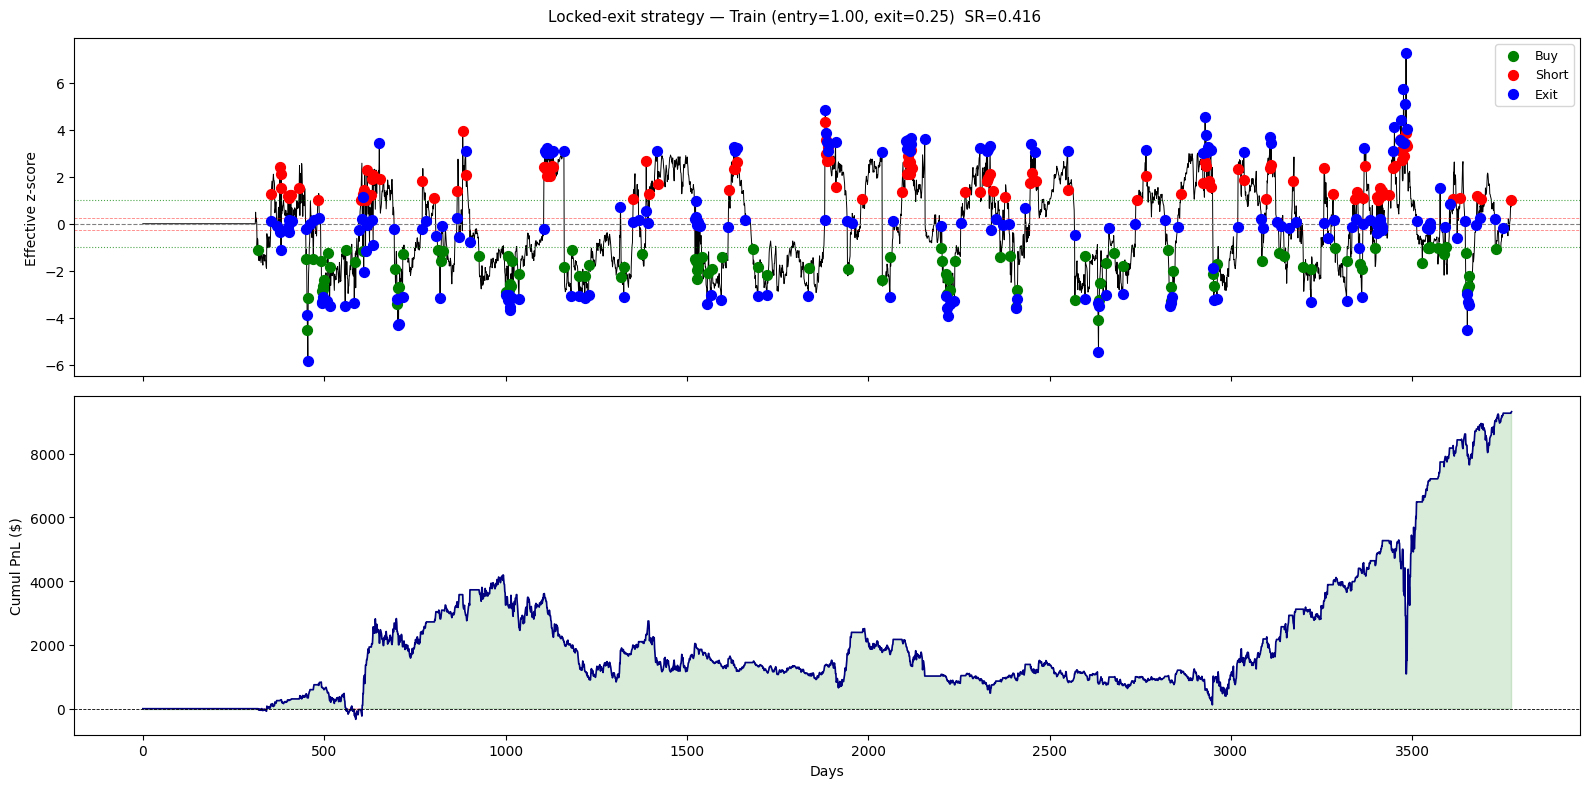

Test: long=258d  short=769d  flat=231d  trades=145  SR=-0.415  ann=-5.26%


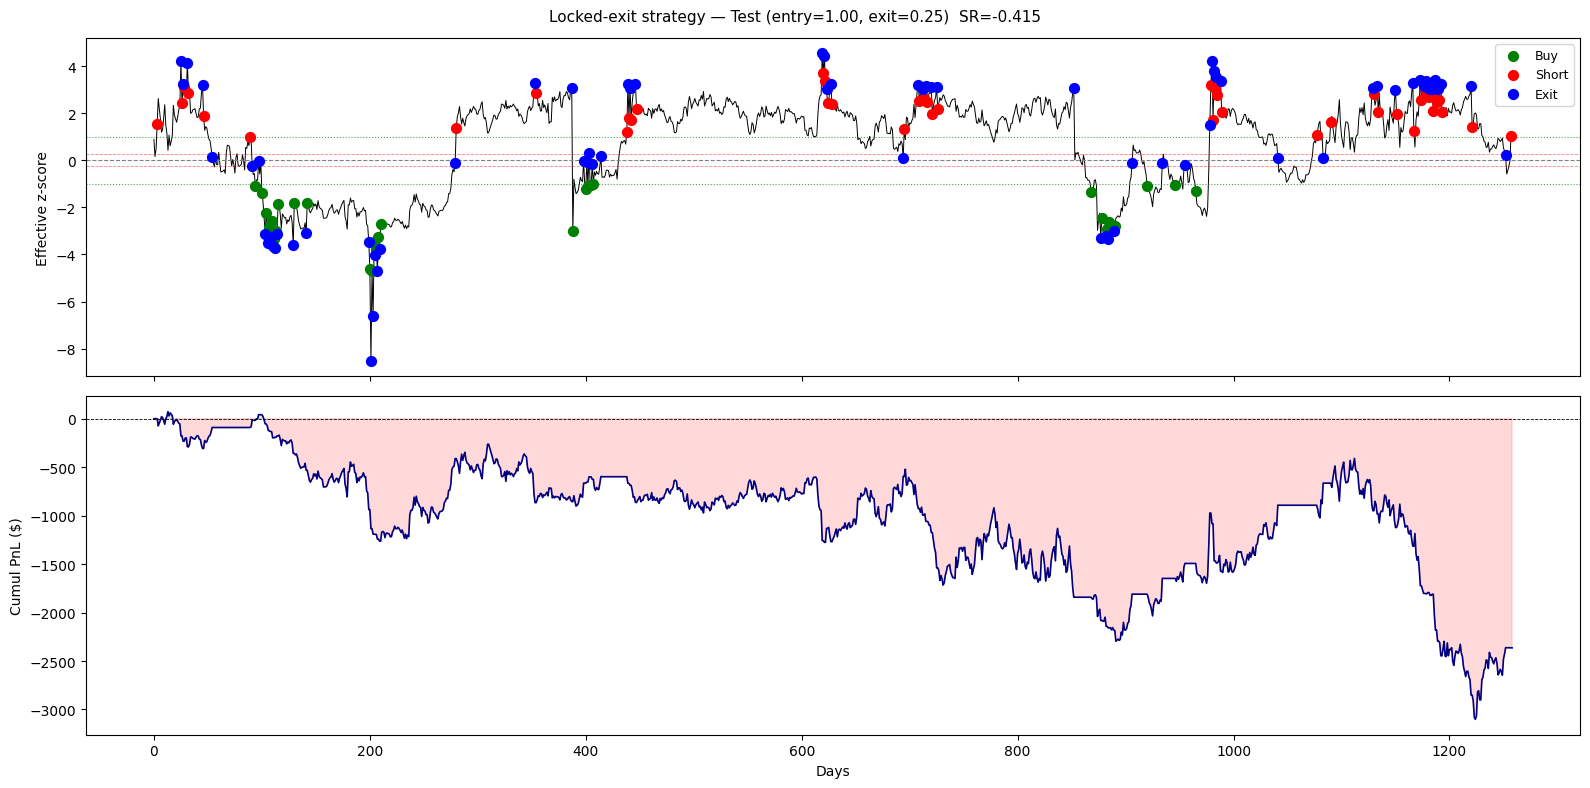

In [37]:
# ── Decision plot for entry-beta-locked strategy ──────────────────────────
# Fixed-reference z: mean/std locked at entry (60 days before entry),
# so the exit z cleanly measures spread displacement from entry baseline.

def run_threshold_locked_debug(prices, log_A, log_B,
                               beta_arr, icp_arr, z_entry_arr,
                               entry_z, exit_z,
                               t_start, t_end,
                               tc=0.0001, z_window=60):
    env = KFEnv(prices, tc=tc, episode_len=t_end - t_start)
    env.reset(t_start=t_start)
    wealth   = [env._wealth()]
    pos_hist = []
    z_eff    = []

    e_beta  = None
    e_icp   = None
    mu_ref  = None   # fixed mean from pre-entry window
    sig_ref = None   # fixed std  from pre-entry window

    for t in range(t_start, t_end):
        pos = env._pos

        if pos == 0:
            z_t = z_entry_arr[t]
            b   = beta_arr[t]
            if np.isnan(z_t) or np.isnan(b):
                direction_idx = 0
            elif z_t < -entry_z:
                direction_idx = 1
                e_beta, e_icp = b, icp_arr[t]
                t0   = max(0, t - z_window)
                hist = log_A[t0:t] - e_beta * log_B[t0:t] - e_icp  # exclude entry day
                mu_ref  = hist.mean()
                sig_ref = hist.std() + 1e-8
            elif z_t > entry_z:
                direction_idx = 2
                e_beta, e_icp = b, icp_arr[t]
                t0   = max(0, t - z_window)
                hist = log_A[t0:t] - e_beta * log_B[t0:t] - e_icp
                mu_ref  = hist.mean()
                sig_ref = hist.std() + 1e-8
            else:
                direction_idx = 0
            z_eff.append(float(z_t) if not np.isnan(z_t) else 0.0)

        else:
            sp  = float(log_A[t] - e_beta * log_B[t] - e_icp)
            z_t = (sp - mu_ref) / sig_ref
            z_eff.append(float(z_t))

            if pos == 1:
                direction_idx = 0 if (z_t > -exit_z or z_t < -3) else 1
            else:
                direction_idx = 0 if (z_t <  exit_z or z_t >  3) else 2

            if direction_idx == 0:
                e_beta = e_icp = mu_ref = sig_ref = None

        env.step((direction_idx, e_beta if e_beta is not None else beta_arr[t]))
        pos_hist.append(env._pos)
        wealth.append(env._wealth())

    if env._pos != 0:
        env.step((0, 0.0))
        wealth[-1] = env._wealth()

    return np.array(wealth), np.array(pos_hist), np.array(z_eff)


en_best, ex_best = best_params

W_tr, pos_tr, z_tr = run_threshold_locked_debug(
    prices, log_xom, log_cvx, beta_hl, icp_hl, z_hl.values,
    en_best, ex_best, t_start=0, t_end=train_end)

W_te, pos_te, z_te = run_threshold_locked_debug(
    prices, log_xom, log_cvx, beta_hl, icp_hl, z_hl.values,
    en_best, ex_best, t_start=train_end, t_end=N)

for label, W, pos, z_e in [
    ('Train', W_tr, pos_tr, z_tr),
    ('Test',  W_te, pos_te, z_te),
]:
    T       = len(pos)
    t_x     = np.arange(T)
    pos_ext = np.concatenate([[0], pos])

    prev_pos  = np.concatenate([[0], pos[:-1]])
    buy_idx   = np.where((pos ==  1) & (prev_pos !=  1))[0]
    short_idx = np.where((pos == -1) & (prev_pos != -1))[0]
    exit_idx  = np.where((pos ==  0) & (prev_pos !=  0))[0]

    n_trades = int((np.diff(pos_ext) != 0).sum())
    print(f'{label}: long={int((pos==1).sum())}d  short={int((pos==-1).sum())}d  '
          f'flat={int((pos==0).sum())}d  trades={n_trades}  '
          f'SR={sharpe(W):.3f}  ann={ann_ret(W)*100:+.2f}%')

    fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
    fig.suptitle(f'Locked-exit strategy — {label} '
                 f'(entry={en_best:.2f}, exit={ex_best:.2f})  SR={sharpe(W):.3f}', fontsize=11)

    ax = axes[0]
    ax.plot(t_x, z_e, color='black', lw=0.7, zorder=1)
    ax.axhline(0,        color='gray',  lw=0.8, ls='--')
    ax.axhline( en_best, color='green', lw=0.8, ls=':', alpha=0.7)
    ax.axhline(-en_best, color='green', lw=0.8, ls=':', alpha=0.7)
    ax.axhline( ex_best, color='red',   lw=0.6, ls='--', alpha=0.5)
    ax.axhline(-ex_best, color='red',   lw=0.6, ls='--', alpha=0.5)
    ax.scatter(buy_idx,   z_e[buy_idx],   color='green', s=50, zorder=3, label='Buy')
    ax.scatter(short_idx, z_e[short_idx], color='red',   s=50, zorder=3, label='Short')
    ax.scatter(exit_idx,  z_e[exit_idx],  color='blue',  s=50, zorder=3, label='Exit')
    ax.set_ylabel('Effective z-score')
    ax.legend(fontsize=9)

    ax = axes[1]
    t_w = np.arange(T + 1)
    ax.plot(t_w, W - W[0], color='navy', lw=1.2)
    ax.axhline(0, color='black', lw=0.6, ls='--')
    ax.fill_between(t_w, W - W[0], 0, where=(W >= W[0]), alpha=0.15, color='green')
    ax.fill_between(t_w, W - W[0], 0, where=(W  < W[0]), alpha=0.15, color='red')
    ax.set_ylabel('Cumul PnL ($)'); ax.set_xlabel('Days')

    plt.tight_layout(); plt.show()


ep  100  eps=0.762  reward=  -139.2  wealth=9861
ep  200  eps=0.525  reward=   +26.4  wealth=10026
ep  300  eps=0.287  reward=  +264.4  wealth=10264
ep  400  eps=0.050  reward=  +401.6  wealth=10402
ep  500  eps=0.050  reward=  +485.9  wealth=10486
ep  600  eps=0.050  reward=  +806.1  wealth=10806
ep  700  eps=0.050  reward=  +932.0  wealth=10932
ep  800  eps=0.050  reward=  +623.0  wealth=10623
Training done.
Train: long=2643d  short=596d  flat=182d  trades=262  SR=0.224  ann=+2.44%


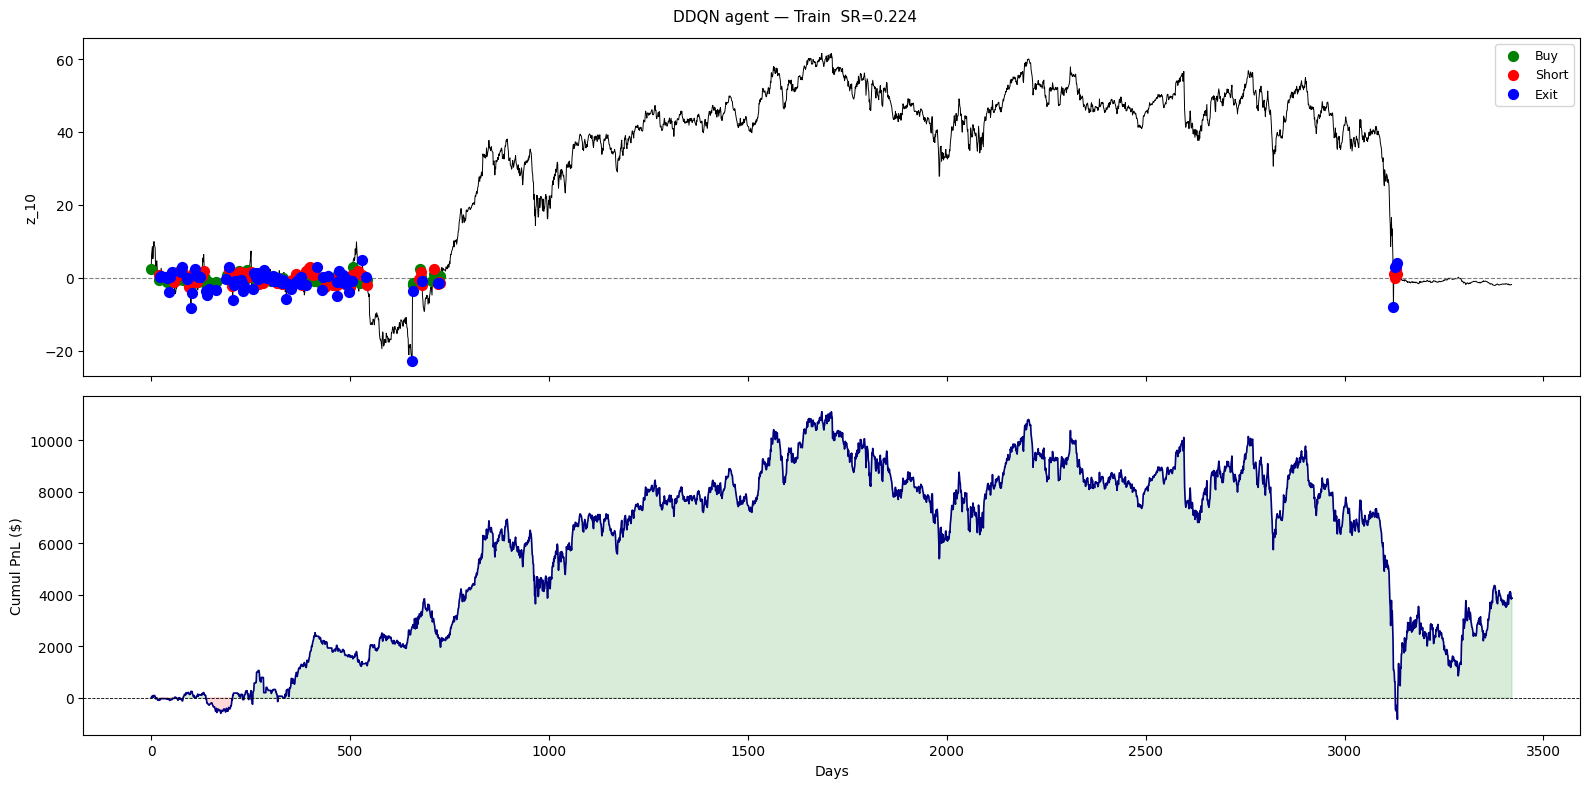

Test: long=1086d  short=97d  flat=75d  trades=114  SR=0.062  ann=+0.18%


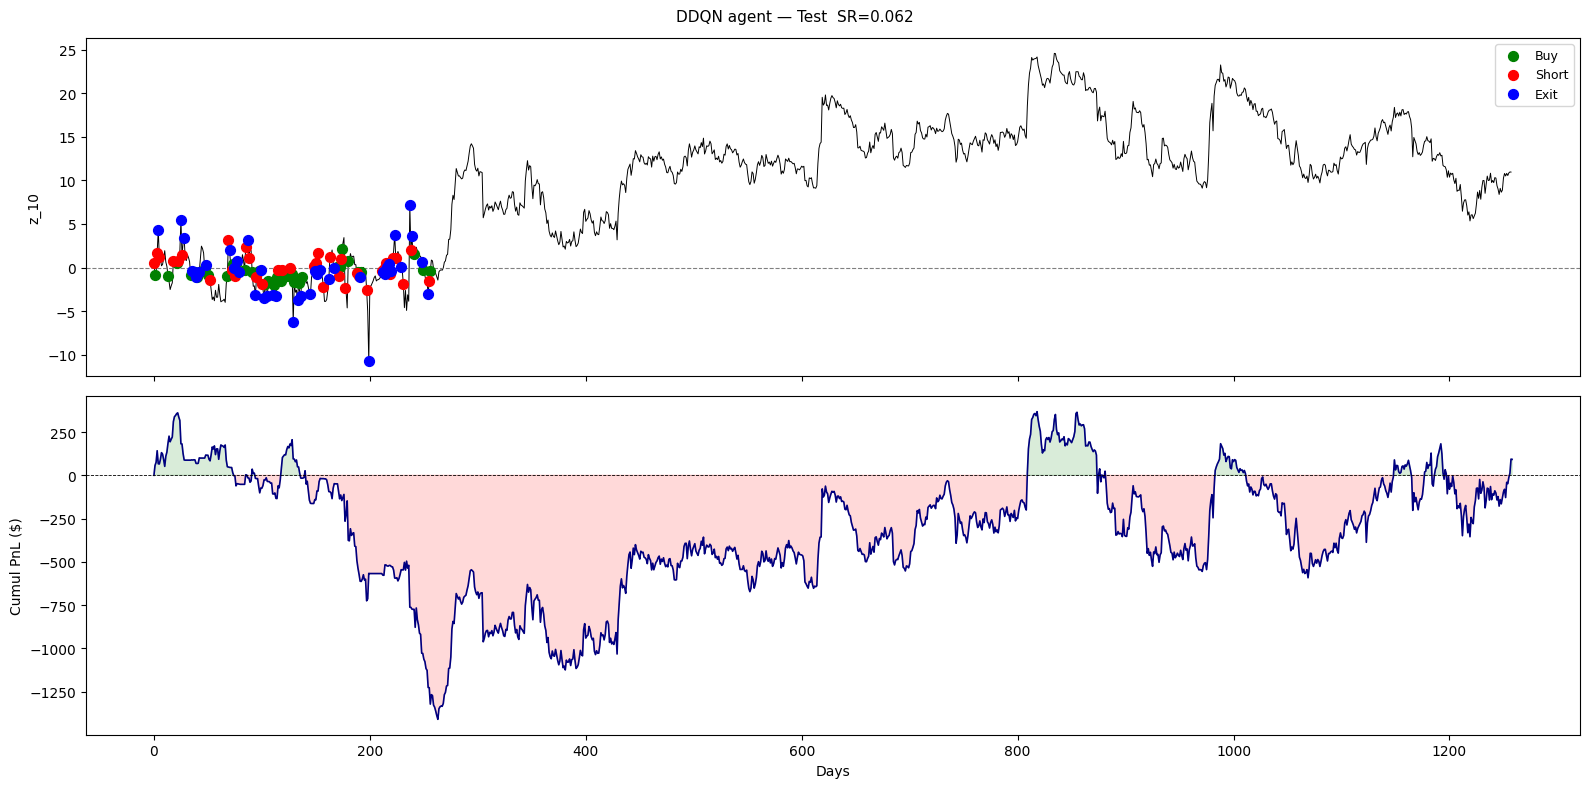

In [38]:
# ── RL on min-HL spread ────────────────────────────────────────────────────
import sys; sys.path.insert(0, '..')
from ddqn_v2 import DoubleDQN

# ── Multi-window z-scores precomputed for flat state ──────────────────────
_WINS    = (10, 45, 100)
_z_multi = np.column_stack([rolling_z(spread_hl, w).values for w in _WINS])  # (N, 3)

# ── Environment (plain class, no gym overhead) ─────────────────────────────
class SpreadRLEnv:
    _W = (10, 45, 100)

    def __init__(self, prices, log_A, log_B, beta_arr, icp_arr,
                 z_multi, spread_arr,
                 initial_wealth=10_000, tc=0.0001, episode_len=252):
        self.prices      = prices.astype(np.float64)
        self.log_A       = log_A;       self.log_B      = log_B
        self.beta_arr    = beta_arr;    self.icp_arr    = icp_arr
        self.z_multi     = z_multi;     self.spread_arr = spread_arr
        self.W0          = float(initial_wealth)
        self.tc          = float(tc)
        self.episode_len = int(episode_len)
        self.N           = prices.shape[1]

    def _safe_t(self): return min(self._t, self.N - 1)

    def _wealth(self):
        return float(self._cash + self._shares @ self.prices[:, self._safe_t()])

    def _obs(self):
        t = self._safe_t()
        if self._pos == 0:
            sp = float(self.spread_arr[t]) if not np.isnan(self.spread_arr[t]) else 0.
            z  = np.where(np.isnan(self.z_multi[t]), 0., self.z_multi[t]).astype(np.float32)
        else:
            sp = float(self.log_A[t] - self._e_beta * self.log_B[t] - self._e_icp)
            z  = ((sp - self._mu_ref) / self._sig_ref).astype(np.float32)
        return np.array([sp, z[0], z[1], z[2], float(self._pos)], np.float32)

    def _enter(self, direction, beta):
        t = self._safe_t()
        p0, p1 = self.prices[0, t], self.prices[1, t]
        C = self._wealth()
        d0, d1 = C / (1 + beta), beta * C / (1 + beta)
        self._shares[0] =  direction * d0 / p0
        self._shares[1] = -direction * d1 / p1
        self._cash     += direction * (d1 - d0) - self.tc * (d0 + d1)
        self._pos = direction; self._e_beta = beta; self._e_icp = self.icp_arr[t]
        for i, w in enumerate(self._W):
            t0   = max(0, t - w)
            hist = self.log_A[t0:t] - beta * self.log_B[t0:t] - self._e_icp
            self._mu_ref[i]  = hist.mean() if len(hist) > 0 else 0.
            self._sig_ref[i] = hist.std() + 1e-8 if len(hist) > 1 else 1.

    def _exit(self):
        t = self._safe_t()
        p0, p1 = self.prices[0, t], self.prices[1, t]
        notional = abs(self._shares[0])*p0 + abs(self._shares[1])*p1
        self._cash = self._wealth() - self.tc * notional
        self._shares[:] = 0; self._pos = 0; self._e_beta = self._e_icp = None

    def reset(self, t_start=0):
        self._t      = int(t_start)
        self._end    = self._t + self.episode_len
        self._cash   = self.W0
        self._shares = np.zeros(2); self._pos = 0
        self._e_beta = self._e_icp = None
        self._mu_ref = np.zeros(3); self._sig_ref = np.ones(3)
        return self._obs()

    def step(self, action):
        desired = {0: 0, 1: 1, 2: -1}[int(action)]
        # stop-loss: force exit if locked z moves > 3 against position
        if self._pos != 0:
            t  = self._safe_t()
            sp = float(self.log_A[t] - self._e_beta * self.log_B[t] - self._e_icp)
            z10 = (sp - self._mu_ref[0]) / self._sig_ref[0]
            if (self._pos == 1 and z10 < -3) or (self._pos == -1 and z10 > 3):
                desired = 0
        old_w = self._wealth()
        if desired != self._pos:
            if self._pos != 0: self._exit()
            if desired   != 0: self._enter(desired, float(self.beta_arr[self._safe_t()]))
        self._t += 1
        done = bool(self._t >= self._end)
        return self._obs(), float(self._wealth() - old_w), done, False, {}


# ── Training ───────────────────────────────────────────────────────────────
SEED         = 42
N_EPISODES   = 800
EPISODE_LEN  = 252
TRAIN_FREQ   = 4
LOG_EVERY    = 100

T0_MIN = int(HL_LOOKBACK + max(_WINS) + 1)   # ensure beta_hl and z are valid
T0_MAX = int(train_end - EPISODE_LEN - 1)

rng = np.random.default_rng(SEED)

env_rl = SpreadRLEnv(prices, log_xom, log_cvx, beta_hl, icp_hl,
                     _z_multi, spread_hl, episode_len=EPISODE_LEN)

agent = DoubleDQN(
    state_dim       = 5,
    action_dim      = 3,
    hidden          = 64,
    lr              = 3e-4,
    gamma           = 0.99,
    tau             = 0.005,
    buffer_size     = int(1e5),
    batch_size      = 256,
    eps_start       = 1.0,
    eps_end         = 0.05,
    eps_decay_steps = N_EPISODES * EPISODE_LEN // 2,
    grad_clip       = 1.0,
)

ep_rewards = []; ep_wealth = []; total_steps = 0

for ep in range(N_EPISODES):
    t0  = int(rng.integers(T0_MIN, T0_MAX + 1))
    obs = env_rl.reset(t_start=t0)
    done = False; ep_r = 0.

    while not done:
        action = agent.select_action(obs)
        obs2, r, done, _, _ = env_rl.step(action)
        agent.replay_buffer.add(obs.copy(), action, r, obs2.copy(), done)
        obs = obs2; ep_r += r; total_steps += 1
        if total_steps % TRAIN_FREQ == 0:
            agent.train()

    ep_rewards.append(ep_r); ep_wealth.append(env_rl._wealth())

    if (ep + 1) % LOG_EVERY == 0:
        print(f'ep {ep+1:4d}  eps={agent.epsilon:.3f}  '
              f'reward={np.mean(ep_rewards[-LOG_EVERY:]):+8.1f}  '
              f'wealth={np.mean(ep_wealth[-LOG_EVERY:]):.0f}')

print('Training done.')


# ── Evaluate + decision plot ───────────────────────────────────────────────
def eval_agent(t_start, t_end):
    env = SpreadRLEnv(prices, log_xom, log_cvx, beta_hl, icp_hl,
                      _z_multi, spread_hl, episode_len=t_end - t_start)
    obs = env.reset(t_start=t_start)
    wealth = [env._wealth()]; pos_hist = []; z_eff = []
    done = False
    while not done:
        z_eff.append(float(obs[1]))
        act = agent.select_action(obs, deterministic=True)
        obs, _, done, _, _ = env.step(act)
        pos_hist.append(env._pos); wealth.append(env._wealth())
    if env._pos != 0:
        env._exit(); wealth[-1] = env._wealth()
    return np.array(wealth), np.array(pos_hist), np.array(z_eff)

for label, t0, t1 in [('Train', T0_MIN, train_end), ('Test', train_end, N)]:
    W, pos, ze = eval_agent(t0, t1)
    T = len(pos); t_x = np.arange(T)
    prev    = np.concatenate([[0], pos[:-1]])
    buy_i   = np.where((pos ==  1) & (prev !=  1))[0]
    short_i = np.where((pos == -1) & (prev != -1))[0]
    exit_i  = np.where((pos ==  0) & (prev !=  0))[0]
    n_trades = int((np.diff(np.concatenate([[0], pos])) != 0).sum())
    print(f'{label}: long={int((pos==1).sum())}d  short={int((pos==-1).sum())}d  '
          f'flat={int((pos==0).sum())}d  trades={n_trades}  '
          f'SR={sharpe(W):.3f}  ann={ann_ret(W)*100:+.2f}%')

    fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
    fig.suptitle(f'DDQN agent — {label}  SR={sharpe(W):.3f}', fontsize=11)
    ax = axes[0]
    ax.plot(t_x, ze, color='black', lw=0.7)
    ax.axhline(0, color='gray', lw=0.8, ls='--')
    ax.scatter(buy_i,   ze[buy_i],   color='green', s=50, zorder=3, label='Buy')
    ax.scatter(short_i, ze[short_i], color='red',   s=50, zorder=3, label='Short')
    ax.scatter(exit_i,  ze[exit_i],  color='blue',  s=50, zorder=3, label='Exit')
    ax.set_ylabel('z_10'); ax.legend(fontsize=9)
    ax = axes[1]
    t_w = np.arange(T + 1)
    ax.plot(t_w, W - W[0], color='navy', lw=1.2)
    ax.axhline(0, color='black', lw=0.6, ls='--')
    ax.fill_between(t_w, W-W[0], 0, where=(W>=W[0]), alpha=0.15, color='green')
    ax.fill_between(t_w, W-W[0], 0, where=(W< W[0]), alpha=0.15, color='red')
    ax.set_ylabel('Cumul PnL ($)'); ax.set_xlabel('Days')
    plt.tight_layout(); plt.show()


Train SR=0.224  Test SR=0.452  ann=+3.79%


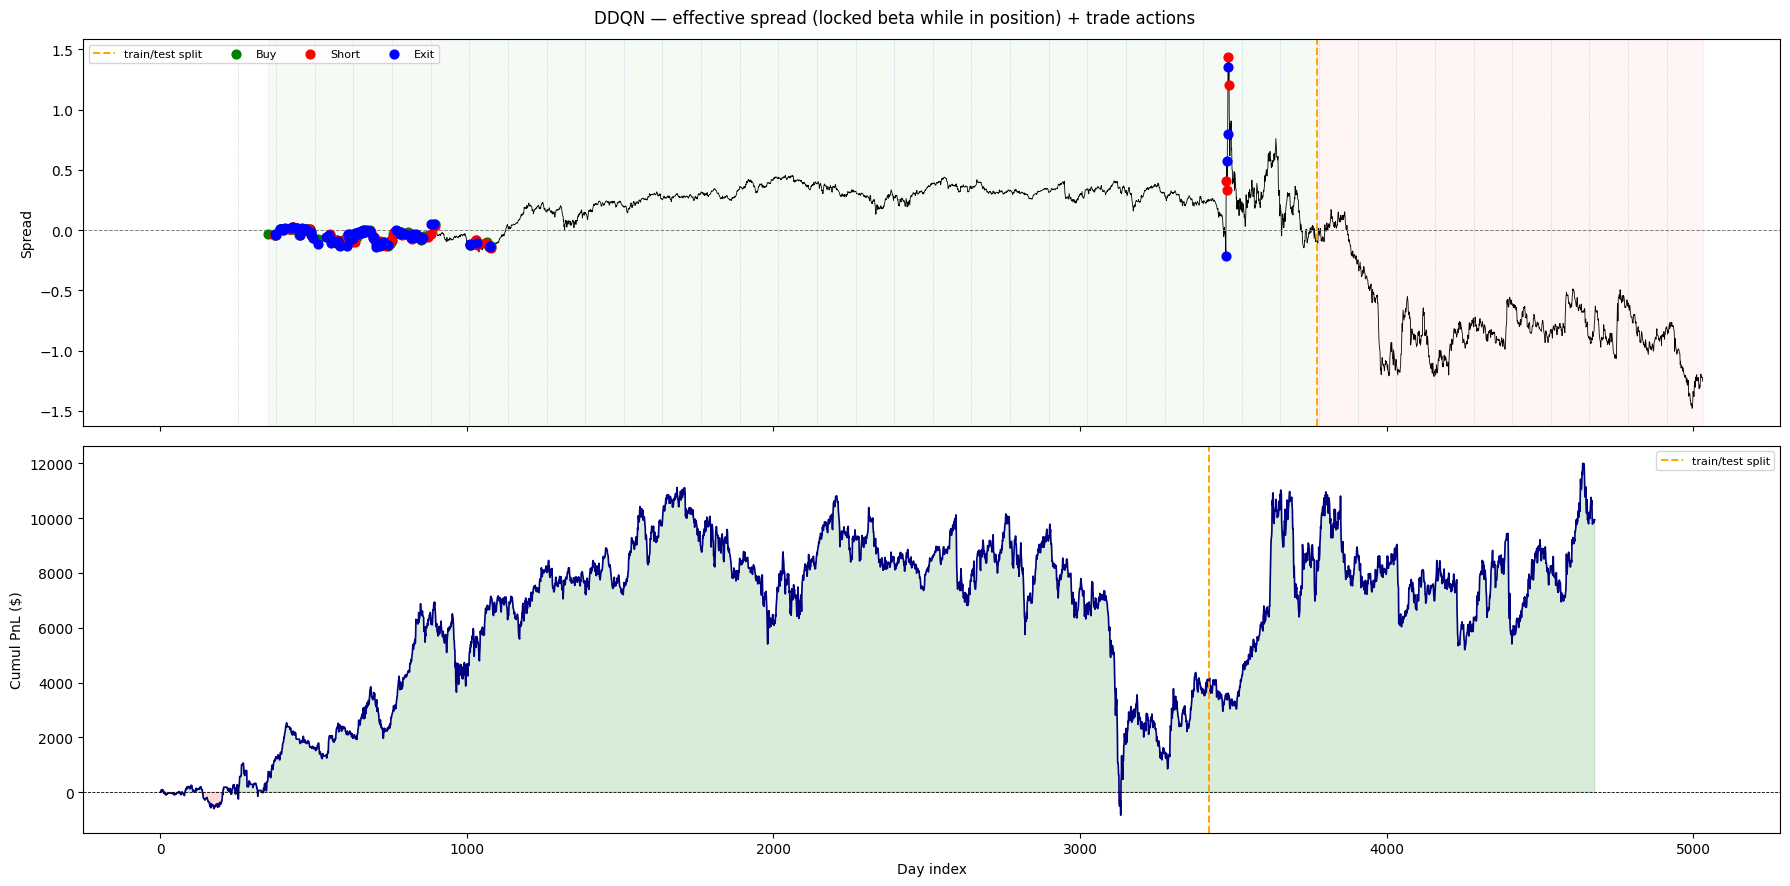

In [39]:
# ── Spread + 6-month sections + agent actions across full dataset ──────────
def eval_agent_full(t_start, t_end):
    env = SpreadRLEnv(prices, log_xom, log_cvx, beta_hl, icp_hl,
                      _z_multi, spread_hl, episode_len=t_end - t_start)
    obs = env.reset(t_start=t_start)
    wealth = [env._wealth()]; pos_hist = []; spread_hist = []
    done = False
    while not done:
        t = env._safe_t()
        if env._pos == 0:
            sp = float(spread_hl[t]) if not np.isnan(spread_hl[t]) else np.nan
        else:
            sp = float(log_xom[t] - env._e_beta * log_cvx[t] - env._e_icp)
        spread_hist.append(sp)
        act = agent.select_action(obs, deterministic=True)
        obs, _, done, _, _ = env.step(act)
        pos_hist.append(env._pos)
        wealth.append(env._wealth())
    if env._pos != 0:
        env._exit(); wealth[-1] = env._wealth()
    return np.array(wealth), np.array(pos_hist), np.array(spread_hist)

W_full, pos_full, sp_full = eval_agent_full(T0_MIN, N)

T     = len(pos_full)
t_abs = np.arange(T0_MIN, T0_MIN + T)
prev  = np.concatenate([[0], pos_full[:-1]])
buy_i = np.where((pos_full ==  1) & (prev !=  1))[0]
sh_i  = np.where((pos_full == -1) & (prev != -1))[0]
ex_i  = np.where((pos_full ==  0) & (prev !=  0))[0]

print(f'Train SR={sharpe(W_full[:train_end-T0_MIN+1]):.3f}  ' 
      f'Test SR={sharpe(W_full[train_end-T0_MIN:]):.3f}  ' 
      f'ann={ann_ret(W_full)*100:+.2f}%')

fig, axes = plt.subplots(2, 1, figsize=(18, 9), sharex=True)
fig.suptitle('DDQN — effective spread (locked beta while in position) + trade actions', fontsize=12)

ax = axes[0]
ax.plot(t_abs, sp_full, color='black', lw=0.6, zorder=1)
ax.axhline(0, color='gray', lw=0.7, ls='--')
for rt in refit_t:
    ax.axvline(rt, color='steelblue', lw=0.6, alpha=0.4, ls=':')
ax.axvline(train_end, color='orange', lw=1.4, ls='--', label='train/test split')
ax.axvspan(T0_MIN,    train_end,   alpha=0.04, color='green')
ax.axvspan(train_end, T0_MIN + T,  alpha=0.04, color='red')
ax.scatter(t_abs[buy_i], sp_full[buy_i], color='green', s=40, zorder=3, label='Buy')
ax.scatter(t_abs[sh_i],  sp_full[sh_i],  color='red',   s=40, zorder=3, label='Short')
ax.scatter(t_abs[ex_i],  sp_full[ex_i],  color='blue',  s=40, zorder=3, label='Exit')
ax.set_ylabel('Spread'); ax.legend(fontsize=8, ncol=5)

ax = axes[1]
t_w = np.arange(T + 1)
split_i = train_end - T0_MIN
ax.plot(t_w, W_full - W_full[0], color='navy', lw=1.2)
ax.axhline(0, color='black', lw=0.6, ls='--')
ax.axvline(split_i, color='orange', lw=1.4, ls='--', label='train/test split')
ax.fill_between(t_w, W_full-W_full[0], 0, where=(W_full>=W_full[0]), alpha=0.15, color='green')
ax.fill_between(t_w, W_full-W_full[0], 0, where=(W_full< W_full[0]), alpha=0.15, color='red')
ax.set_ylabel('Cumul PnL ($)'); ax.set_xlabel('Day index'); ax.legend(fontsize=8)

plt.tight_layout(); plt.show()
